# Porównywanie modeli predykcji szeregów czasowych

## Cel projektu

W naszym projekcie zajmujemy się **analizą i prognozowaniem szeregów czasowych** w kontekście danych finansowych. Głównym celem jest porównanie skuteczności różnych architektur modeli uczenia maszynowego w zadaniu **predykcji ceny zamknięcia (Close) w kolejnym kroku czasowym (t+1)**.

## Podział na kto co robił

| Członek zespołu | Zadanie / Model |
| :--- | :--- |
| **Michał Glinka** | LSTM |
| **Aiman Ghanim** | Meta Prophet |
| **Vitalii Petrychenko** | XGBoost |
| **Jakub Komosa** | GRU, Random Forest, SVR |




## Modele testowane w projekcie

Skupiamy się na **sześciu** fundamentalnie różnych podejściach do modelowania sekwencyjnego:

### 1. **LSTM (Long Short-Term Memory)**
- Architektura sieci neuronowej należąca do rodziny **Recurrent Neural Networks (RNN)**
- Zaprojektowana specjalnie do pracy z danymi sekwencyjnymi
- Wykorzystuje mechanizm **bramek (gates)** do zarządzania przepływem informacji:
  - **Forget gate** — decyduje, które informacje z przeszłości odrzucić
  - **Input gate** — kontroluje, jakie nowe informacje zapamiętać
  - **Output gate** — określa, co przekazać do następnej warstwy
- **Zalety:** zdolność do wykrywania długoterminowych zależności, uczenie nieliniowych wzorców
- **Wyzwania:** wymaga dużej ilości danych, podatność na przeuczenie, dłuższy czas treningu

### 2. **XGBoost (Extreme Gradient Boosting)**
- Model oparty na **zespole drzew decyzyjnych (ensemble learning)**
- Wykorzystuje technikę **gradient boosting** — każde kolejne drzewo poprawia błędy poprzednich
- **Zalety:** 
  - Szybki trening i predykcja
  - Wbudowana regularyzacja (zmniejsza przeuczenie)
  - Dobrze radzi sobie z danymi tabelarycznymi
  - Interpretowalne wyniki (feature importance)
- **Wyzwania:** nie przetwarza natywnie sekwencji — wymaga inżynierii cech (feature engineering)

### 3. **Meta Prophet**
- Biblioteka do prognozowania szeregów czasowych opracowana przez zespół **Meta (Facebook)**
- Wykorzystuje **addytywny model regresyjny** dekomponujący sygnał na trend, sezonowość i efekty specjalne:
  - $y(t) = g(t) + s(t) + h(t) + \epsilon_t$
- **Zalety:**
  - Automatyczna detekcja sezonowości oraz punktów zwrotnych (changepoints)
  - Wysoka odporność na braki danych i wartości odstające
  - Łatwa interpretowalność dzięki wizualizacji poszczególnych komponentów
  - Możliwość dodawania zewnętrznych regresorów (np. wskaźniki techniczne)
- **Wyzwania:**
  - Trudność w modelowaniu bardzo złożonych, nieliniowych zależności krótkoterminowych
  - Założenie o addytywnym charakterze komponentów może być zbyt uproszczone dla dynamicznych danych giełdowych

### 4. **GRU (Gated Recurrent Unit)**
- Uproszczona wersja LSTM z **dwoma bramkami** zamiast trzech (Update + Reset)
- **Zalety:** Szybszy trening, mniej parametrów, porównywalna skuteczność do LSTM
- **Wyzwania:** Może mieć trudności z bardzo długimi zależnościami

### 5. **Random Forest Regressor**
- Ensemble drzew decyzyjnych używający **bagging** (Bootstrap Aggregating)
- **Zalety:** Mniejsza podatność na overfitting niż boosting, interpretowalność
- **Wyzwania:** Wymaga inżynierii cech, nie modeluje natywnie sekwencji

### 6. **SVR (Support Vector Regression)**
- Klasyczny model ML wykorzystujący **podejście geometryczne** z kernel RBF
- **Zalety:** Odporność na outliers, efektywny w wysokowymiarowych przestrzeniach
- **Wyzwania:** Wymaga skalowania danych, wolniejszy na dużych zbiorach

## Uzasadnienie wyboru

Porównanie **6 modeli** z różnych kategorii pozwala zrozumieć:
- Czy modelowanie **sekwencyjne** (LSTM, GRU) przewyższa podejście **tabelaryczne** (XGBoost, RF, SVR) lub **statystyczno-dekompozycyjne** (Prophet)
- Jak **bagging** (RF) wypada względem **boosting** (XGBoost)
- Jaki wpływ ma **inżynieria cech** (technical indicators, makro) na skuteczność modeli
- Jakie trade-offy występują między **złożonością modelu a jakością predykcji**

In [2]:
# Importy bibliotek
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
from prophet import Prophet
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns



import yfinance as yf
import pandas_ta as ta
import sys
import os

import glob
from tensorflow.keras.models import load_model
from prophet.serialize import model_from_json
from prophet.serialize import model_to_json
import joblib
import os
from datetime import datetime
from scipy import stats
from dateutil.relativedelta import relativedelta
from sklearn.metrics import accuracy_score
import xgboost as xgb
from typing import List, Dict, Tuple
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, classification_report





# Seed dla reprodukowalności wyników
np.random.seed(42)
tf.random.set_seed(42)

## Pobranie danych

Dane, na których się skupiamy, to dane finansowe — a dokładniej kurs akcji **Apple Inc. (AAPL)** notowanej na giełdzie **NASDAQ**. Wybór AAPL jest uzasadniony kilkoma czynnikami:

- **Wysoka płynność** — należy do najbardziej aktywnie handlowanych akcji na świecie, co zapewnia ciągłość danych i minimalizuje braki.
- **Długa historia notowań** — dane dostępne od początku 2000 roku pozwalają na uczenie modeli na bogatym zbiorze obejmującym różne cykle rynkowe (hossy, bessy, kryzysy).
- **Reprezentatywność** — jako jeden z liderów sektora technologicznego, AAPL odzwierciedla trendy w całym segmencie tech, co czyni go dobrym benchmarkiem.

Pobrane dane zawierają standardowe informacje OHLCV:
- **Open** — cena otwarcia,
- **High** — najwyższa cena w sesji,
- **Low** — najniższa cena w sesji,
- **Close** — cena zamknięcia (wykorzystywana jako bazowa zmienna),
- **Volume** — wolumen obrotu.

**Zakres czasowy:** od **2000-01-01** do chwili obecnej

In [5]:
# Parametry
TICKER = 'AAPL'
DATA_DIR = 'data'

# Ładowanie danych
cache_path = os.path.join(DATA_DIR, f'{TICKER}.csv')

if os.path.exists(cache_path):
    df = pd.read_csv(cache_path, index_col=0, parse_dates=True)
    print(f"Loaded {len(df)} rows")
else:
    print(f"Cache not found, downloading from Yahoo Finance...")
    df = yf.download(TICKER, start='1990-01-01', auto_adjust=True)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    # Zapis do pliku
    os.makedirs(DATA_DIR, exist_ok=True)
    df.to_csv(cache_path)
    print(f"Saved to cache: {cache_path}")

df

Loaded 9087 rows


,Close,High,Low,Open,Volume
Date,,,,,
1990-01-02,0.260949,0.262700,0.245187,0.246939,183198400
1990-01-03,0.262700,0.266204,0.262700,0.266204,207995200
1990-01-04,0.263577,0.271457,0.260949,0.267955,221513600
1990-01-05,0.264452,0.267955,0.259198,0.264452,123312000
1990-01-08,0.266204,0.266204,0.259198,0.262701,101572800
...,...,...,...,...,...
2026-01-26,255.410004,256.559998,249.800003,251.479996,55969200
2026-01-27,258.269989,261.950012,258.209991,259.170013,49648300
2026-01-28,256.440002,258.859985,254.509995,257.649994,41288000


## Wybieramy najlepsze sygnały

### Dlaczego wykorzystujemy tylko `Close` z OHLC?

W danych dziennych wartości **Open / High / Low / Close** są ze sobą silnie powiązane (w praktyce niosą bardzo podobną informację o poziomie ceny w danym dniu). Dodanie całego OHLC często:
- **zwiększa współliniowość** cech (model dostaje kilka prawie identycznych sygnałów),
- **podnosi wymiarowość wejścia** bez proporcjonalnego wzrostu informacji,
- utrudnia uczenie (więcej parametrów do dopasowania, większe ryzyko przeuczenia),
- daje „szum” zamiast przewagi, szczególnie przy krótszej historii danych.



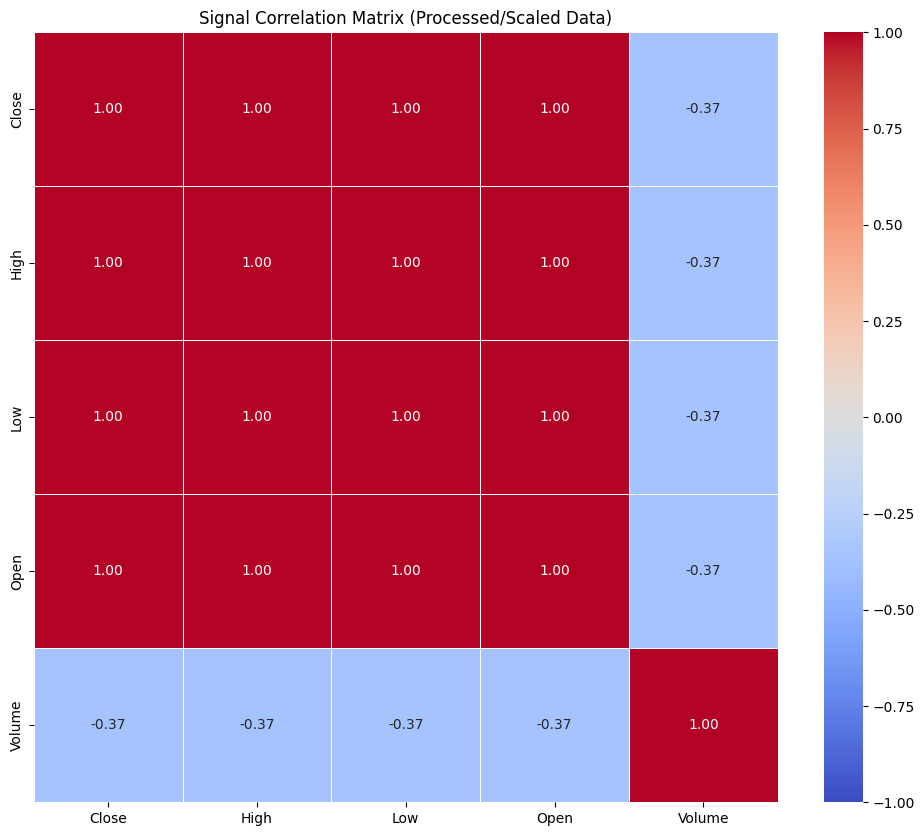

In [6]:
corr_matrix = df.corr()

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Signal Correlation Matrix (Processed/Scaled Data)')
plt.show()



`Close` jest najbardziej reprezentatywną wartością dzienną, bo:
- jest najczęściej używana jako cena referencyjna (wyceny, wskaźniki, zwroty),

### Budowa macierzy sygnalow (Close + techniczne + makro)

Budujemy zestaw cech dziennych, w ktorym kazdy wiersz opisuje ten sam dzien notowan. Jako os czasu przyjmujemy daty z AAPL, a pozostale serie (techniczne i makro) dopasowujemy do tego indeksu.

**Kroki:**
1. Pobieramy dane dzienne AAPL od `START_DATE`.
2. Tworzymy ramke `signals_raw` oparta o `Close` (to nasza bazowa zmienna cenowa).
3. Z `Close` wyliczamy cechy techniczne:
   - `EMA50` jako filtr trendu i wygladzenie szumu,
   - `BB_PB` (Bollinger %B) jako pozycje ceny w kanale zmiennosci.
4. Dodajemy sygnaly zewnetrzne (makro/ryzyko):
   - `VXN` jako proxy oczekiwanej zmiennosci i sentymentu risk-off/risk-on,
   - `DXY` jako kontekst sily dolara (czynnik makro wplywajacy na wyceny i nastroj).
5. Wyrównujemy wszystkie serie po dacie AAPL; brakujace wartosci w danych makro uzupelniamy metoda forward-fill (aby zachowac ciaglosc i spojnosc wejsc).
6. Usuwamy pozostale brakujace obserwacje, aby otrzymac finalna macierz sygnalow gotowa do dalszego przetwarzania (skalowanie, okna sekwencji, podzial train/val/test).


In [7]:
# Inicjalizacja macierzy sygnałów z ceną Close
signals_raw = pd.DataFrame(df["Close"])

# Wskaźniki techniczne
signals_raw["EMA50"] = signals_raw["Close"].ewm(span=50, adjust=False).mean()

# Bollinger Bands %B
sma20 = signals_raw["Close"].rolling(20).mean()
std20 = signals_raw["Close"].rolling(20).std()
upper = sma20 + 2 * std20
lower = sma20 - 2 * std20
signals_raw["BB_PB"] = (signals_raw["Close"] - lower) / (upper - lower)

# Wskaźniki makro/ryzyko - ładowanie z cache
vxn_path = os.path.join(DATA_DIR, 'VXN.csv')
dxy_path = os.path.join(DATA_DIR, 'DXY.csv')

if os.path.exists(vxn_path):
    print(f"Loading VXN from cache")
    vxn = pd.read_csv(vxn_path, index_col=0, parse_dates=True)
    signals_raw['VXN'] = vxn['Close']
else:
    print("VXN cache not found, downloading...")
    vxn = yf.download('^VXN', start='1990-01-01', auto_adjust=True, progress=False)
    signals_raw['VXN'] = vxn['Close']

if os.path.exists(dxy_path):
    print(f"Loading DXY from cache")
    dxy = pd.read_csv(dxy_path, index_col=0, parse_dates=True)
    signals_raw['DXY'] = dxy['Close']
else:
    print("DXY cache not found, downloading...")
    dxy = yf.download('DX-Y.NYB', start='1990-01-01', auto_adjust=True, progress=False)
    signals_raw['DXY'] = dxy['Close']

# Uzupełnianie luk metodą forward-fill
signals_raw['DXY'] = signals_raw['DXY'].ffill()
signals_raw['VXN'] = signals_raw['VXN'].ffill()

print(f"Signals shape: {signals_raw.shape}")
signals_raw

Loading VXN from cache
Loading DXY from cache
Signals shape: (9087, 5)


,Close,EMA50,BB_PB,VXN,DXY
Date,,,,,
1990-01-02,0.260949,0.260949,NaN,NaN,94.290001
1990-01-03,0.262700,0.261018,NaN,NaN,94.419998
1990-01-04,0.263577,0.261118,NaN,NaN,92.519997
1990-01-05,0.264452,0.261249,NaN,NaN,92.849998
1990-01-08,0.266204,0.261443,NaN,NaN,92.050003
...,...,...,...,...,...
2026-01-26,255.410004,263.360137,0.353451,20.430000,97.040001
2026-01-27,258.269989,263.160523,0.452205,20.549999,96.220001
2026-01-28,256.440002,262.896974,0.417185,20.370001,96.449997


### Czyszczenie danych

Aby zapewnić spójność i porównywalność obserwacji w czasie, usuwamy rekordy zawierające braki danych (`NaN`). Braki pojawiają się głównie z dwóch powodów:

- **Okna wskaźników technicznych (lookback window)**  
  Część cech wymaga określonej liczby wcześniejszych notowań, aby mogła zostać policzona.  
  Przykładowo **EMA50** potrzebuje historii z poprzednich dni — dlatego pierwsze ~50 obserwacji nie ma jeszcze pełnej wartości EMA i jest oznaczone jako niekompletne.

- **Niespójne daty pomiędzy źródłami**  
  Dane z różnych indeksów / instrumentów (np. VXN, DXY i AAPL) mogą mieć luki wynikające z różnych kalendarzy handlowych lub braków w danych źródłowych. W takich przypadkach dla części dni nie da się zbudować pełnego wektora cech.

W praktyce stosujemy zasadę: **zostawiamy tylko te dni, dla których wszystkie sygnały wejściowe są dostępne**.  
Dzięki temu każda próbka wejściowa ma kompletny zestaw cech, a model nie uczy się na „pół-kompletnych” obserwacjach, co stabilizuje trening i zmniejsza ryzyko błędów w przetwarzaniu danych.


In [8]:
data = signals_raw.copy()

# Usunięcie wierszy z brakującymi wartościami
data.dropna(inplace=True)

# Weryfikacja: pierwsze 20 wierszy
data.head(20)

,Close,EMA50,BB_PB,VXN,DXY
Date,,,,,
2001-01-23,0.307408,0.281801,1.037236,58.570000,110.239998
2001-01-24,0.307408,0.282806,0.962151,60.660000,111.680000
2001-01-25,0.298973,0.283440,0.847791,63.480000,111.610001
2001-01-26,0.293350,0.283828,0.771026,62.459999,111.459999
2001-01-29,0.325216,0.285451,0.989930,62.400002,111.769997
2001-01-30,0.326153,0.287047,0.944179,62.500000,110.980003
2001-01-31,0.324278,0.288507,0.892183,61.450001,110.519997
2001-02-01,0.316780,0.289616,0.795794,60.490002,109.660004
2001-02-02,0.309283,0.290387,0.708638,63.750000,110.320000


## LSTM (Long Short-Term Memory)

### Implementacja LSTM z differencing

$$ \Delta y_t = y_t - y_{t-1} $$


Tworzymy model LSTM analogicznie do XGBoost i Prophet:
- **Differencing**: Przewidujemy różnice dolarowe zamiast cen bezpośrednio
- **Sekwencje**: Używamy okien czasowych (lookback_window = 60 dni)
- **Podział danych**: 95% train / 5% test (jak w XGBoost i Prophet)
- **Cechy**: 5 sygnałów (Close, EMA50, BB_PB, VXN, DXY)

In [9]:
def create_lstm_model(lookback: int = 60):

    lstm_data = data.copy()
    
    # Obliczamy target - różnica dolarowa
    # Diff_T1 = ile $ się zmieni cena następnego dnia
    lstm_data['Diff_T1'] = lstm_data['Close'].shift(-1) - lstm_data['Close']
    
    # Usuwamy wiersze z NaN (ostatni wiersz przez shift)
    lstm_data = lstm_data.dropna()
    
    # Krok 2: Skalowanie danych (LSTM wymaga normalizacji)
    # Skalujemy wszystkie cechy do [0, 1]
    scaler_features = MinMaxScaler()
    scaler_target = MinMaxScaler()
    
    # Cechy (X)
    features_cols = ['Close', 'EMA50', 'BB_PB', 'VXN', 'DXY']
    scaled_features = scaler_features.fit_transform(lstm_data[features_cols])
    
    # Target (y) - różnice mogą być ujemne, więc też skalujemy
    scaled_target = scaler_target.fit_transform(lstm_data[['Diff_T1']])
    
    # Krok 3: Tworzenie sekwencji (okna czasowe)
    # LSTM potrzebuje danych w formacie 3D: [samples, timesteps, features]
    # Dla każdego dnia bierzemy ostatnie 'lookback' dni jako kontekst
    X, y = [], []
    
    for i in range(lookback, len(scaled_features)):
        # X: ostatnie 60 dni (lookback) wszystkich 5 cech
        X.append(scaled_features[i-lookback:i])
        # y: różnica $ na dzień i (którą chcemy przewidzieć)
        y.append(scaled_target[i])
    
    X = np.array(X)  # kształt: (samples, 60, 5)
    y = np.array(y)  # kształt: (samples, 1)
    
    print(f"   Sekwencje: X shape = {X.shape}, y shape = {y.shape}")
    
    # Krok 4: Podział train/test
    # bez shuffle, bo to szereg czasowy
    split_idx = int(len(X) * 0.95)
    
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    
    print(f"   Train: {len(X_train)} sekwencji")
    print(f"   Test:  {len(X_test)} sekwencji")
    
    # Krok 5: Budowa modelu LSTM
    # Architektura: 2 warstwy LSTM + Dropout + Dense
    model = Sequential([
        # Pierwsza warstwa LSTM (50 neuronów, return_sequences=True żeby móc stackować)
        LSTM(50, return_sequences=True, input_shape=(lookback, len(features_cols))),
        Dropout(0.2),  # Dropout 20% żeby zapobiec przeuczeniu
        
        # Druga warstwa LSTM (50 neuronów)
        LSTM(50, return_sequences=False),
        Dropout(0.2),
        
        # Warstwa wyjściowa
        Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    # Krok 6: Trenowanie modelu
    
    # Early stopping - zatrzymaj jeśli model przestaje się poprawiać
    early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)
    
    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.1,  # 10% z train jako validation
        callbacks=[early_stop],
        verbose=1
    )
        
    # Zwracamy model, dane testowe i scalery (potrzebne do odwrócenia skalowania)
    return model, X_test, y_test, scaler_features, scaler_target, lstm_data.iloc[split_idx+lookback:]

### Predykcje LSTM i przeliczanie różnic na ceny

Proces:
1. Model przewiduje skalowane różnice
2. Odwracamy skalowanie (de-normalizacja)
3. Przeliczamy różnice na ceny: `Predicted_Close = Current_Close + Predicted_Diff`

In [10]:
def predict_lstm(model, X_test, scaler_features, scaler_target, test_data_original):
    
    # Krok 1: Predykcja (model zwraca skalowane różnice)
    y_pred_scaled = model.predict(X_test, verbose=0)
    
    # Krok 2: Odwrócenie skalowania (z [0,1] z powrotem na $)
    y_pred_diff = scaler_target.inverse_transform(y_pred_scaled).flatten()
    
    # Krok 3: Przygotowanie danych do porównania
    # Bierzemy obecne ceny Close z oryginalnych danych
    results = pd.DataFrame({
        'Date': test_data_original.index,
        'Curr_Close': test_data_original['Close'].values,
        'Next_Close': test_data_original['Close'].shift(-1).values,
    })
    
    # Krok 4: Przeliczamy różnice na ceny
    # Logika: jeśli dzisiaj 100$ i model przewidział +5$, to jutro 105$
    results['Predicted_Diff'] = y_pred_diff
    results['Predicted_Close'] = results['Curr_Close'] + results['Predicted_Diff']
    
    # Rzeczywista cena
    results['Actual_Close'] = results['Next_Close']
    
    # Usuwamy ostatni wiersz (nie ma Next_Close)
    results = results.dropna()
    
    return results[['Date', 'Actual_Close', 'Predicted_Close']]

In [29]:
# Trenowanie LSTM
model_lstm, X_test_lstm, y_test_lstm, scaler_feat, scaler_targ, test_data_lstm = create_lstm_model(lookback=60)


   Sekwencje: X shape = (6232, 60, 5), y shape = (6232, 1)
   Train: 5920 sekwencji
   Test:  312 sekwencji
Epoch 1/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0070 - mae: 0.0596 - val_loss: 0.0038 - val_mae: 0.0466
Epoch 2/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0018 - mae: 0.0328 - val_loss: 0.0044 - val_mae: 0.0515
Epoch 3/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0016 - mae: 0.0302 - val_loss: 0.0059 - val_mae: 0.0627
Epoch 4/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0014 - mae: 0.0285 - val_loss: 0.0037 - val_mae: 0.0460
Epoch 5/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0012 - mae: 0.0261 - val_loss: 0.0044 - val_mae: 0.0511
Epoch 6/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0011 - mae: 0.0254 - val_loss: 0.0039 - val_mae: 0.0474
Epoch 7/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0011 - mae: 0.0241 - val_loss: 0.0045 - val_mae: 0.0519
Epoch 8/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss

In [30]:
# Predykcje
results_lstm = predict_lstm(model_lstm, X_test_lstm, scaler_feat, scaler_targ, test_data_lstm)

results_lstm.info()

<class 'pandas.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             311 non-null    datetime64[us]
 1   Actual_Close     311 non-null    float64       
 2   Predicted_Close  311 non-null    float64       
dtypes: datetime64[us](1), float64(2)
memory usage: 7.4 KB


In [31]:
results_lstm.tail(10)

,Date,Actual_Close,Predicted_Close
301,2026-01-14,258.209991,259.961130
302,2026-01-15,255.529999,258.209283
303,2026-01-16,246.699997,255.528617
304,2026-01-20,247.649994,246.698866
305,2026-01-21,248.350006,247.649125
306,2026-01-22,248.039993,248.349738
307,2026-01-23,255.410004,248.040247
308,2026-01-26,258.269989,255.410207
309,2026-01-27,256.440002,258.268328
310,2026-01-28,258.279999,256.435830


### Metryki ewaluacyjne LSTM

Obliczamy te same metryki co dla XGBoost i Prophet:
- **MAE** — Mean Absolute Error
- **RMSE** — Root Mean Squared Error
- **MAPE** — Mean Absolute Percentage Error
- **R²** — Coefficient of Determination

In [32]:
# Obliczanie metryk dla LSTM
y_true_lstm = results_lstm['Actual_Close'].values
y_pred_lstm = results_lstm['Predicted_Close'].values

mae_lstm = mean_absolute_error(y_true_lstm, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_true_lstm, y_pred_lstm))
mape_lstm = np.mean(np.abs((y_true_lstm - y_pred_lstm) / y_true_lstm)) * 100
r2_lstm = r2_score(y_true_lstm, y_pred_lstm)

print("="*60)
print(" METRYKI EWALUACYJNE - LSTM")
print("="*60)
print(f"MAE (Mean Absolute Error):       ${mae_lstm:.4f}")
print(f"RMSE (Root Mean Squared Error):  ${rmse_lstm:.4f}")
print(f"MAPE (Mean Absolute % Error):    {mape_lstm:.4f}%")
print(f"R² (Coefficient of Determination): {r2_lstm:.4f}")
print("="*60)

 METRYKI EWALUACYJNE - LSTM
MAE (Mean Absolute Error):       $2.6984
RMSE (Root Mean Squared Error):  $4.0493
MAPE (Mean Absolute % Error):    1.1945%
R² (Coefficient of Determination): 0.9739


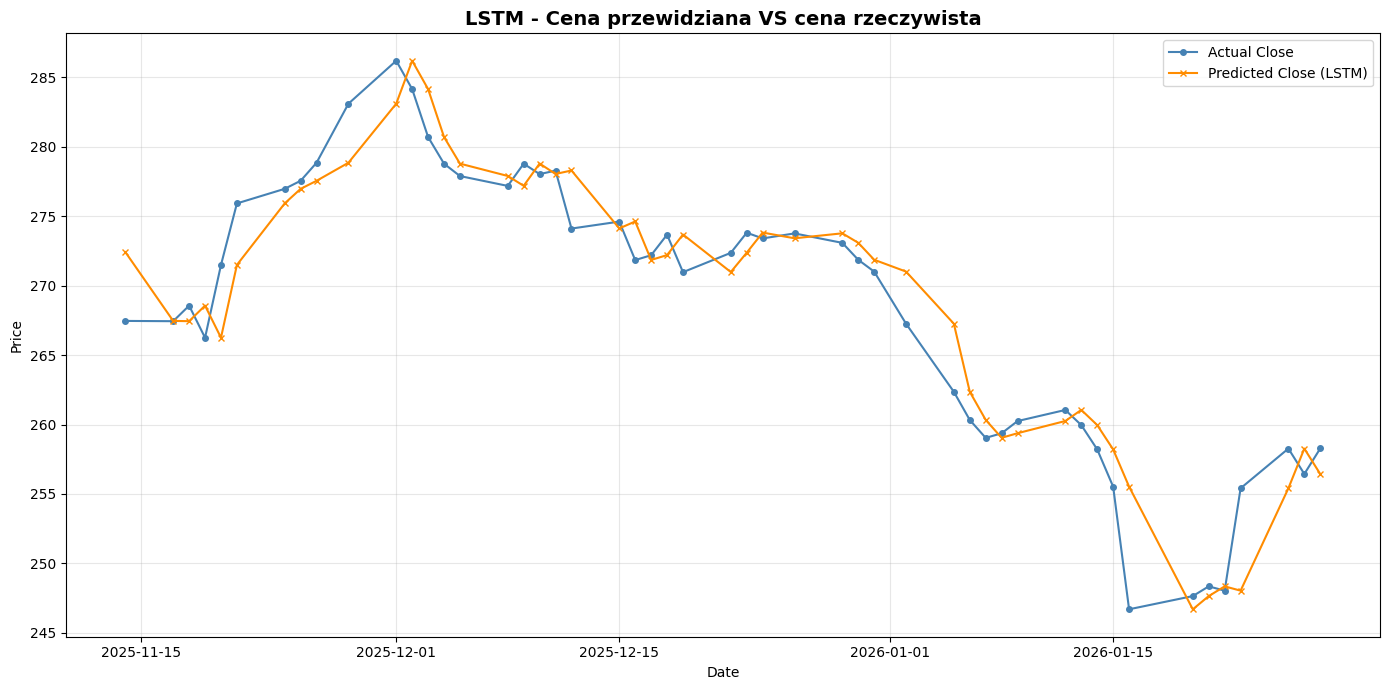

In [33]:
# Wizualizacja wyników LSTM
plt.figure(figsize=(14, 7))
plt.plot(results_lstm['Date'][-50:], results_lstm['Actual_Close'][-50:], label='Actual Close',  marker='o', markersize=4, color='steelblue')
plt.plot(results_lstm['Date'][-50:], results_lstm['Predicted_Close'][-50:], label='Predicted Close (LSTM)', marker='x', markersize=4, color='darkorange')

plt.title('LSTM - Cena przewidziana VS cena rzeczywista', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## XGBoost

XGBoost (Extreme Gradient Boosting) to model oparty na **zespole drzew decyzyjnych**. Wykorzystuje technikę gradient boosting - każde kolejne drzewo poprawia błędy poprzednich.

**Kluczowe cechy:**
- Szybki trening i predykcja
- Wbudowana regularyzacja (L1, L2)
- Interpretowalność przez feature importance
- Wymaga inżynierii cech (lagi) dla szeregów czasowych

**Nasze podejście:** Tworzymy 100 lagów dla każdej z 5 zmiennych (Close, EMA50, BB_PB, VXN, DXY), co daje 500 features wejściowych. Target: Return_T1 (procentowa zmiana ceny).

In [34]:
# Dodajemy lagi do danych do xgboosta
def create_xgboost_model(
    lag: int = 50,
):
    xgb_data = data.copy()

    xgb_data['Return'] = xgb_data['Close'].pct_change()

    # Target: zwrot % 
    xgb_data['Diff_T1'] = xgb_data['Close'].shift(-1) / xgb_data['Close'] - 1
    
    lagged_feature_cols = ['Close', 'EMA50', 'BB_PB', 'VXN', 'DXY']
    # kreujemy lagi sygnałów
    for col in lagged_feature_cols:
        for l in range(1, lag + 1):
            key = f'{col}_lag_{l}'
            xgb_data[key] = xgb_data[col].shift(l)

    # usówamy wiersz pusty po przesunięciu
    xgb_data = xgb_data.dropna()

    features_cols = [col for col in xgb_data.columns if col not in ['Close', 'Diff_T1']]
    
    
    X = xgb_data[features_cols]
    y = xgb_data['Diff_T1']

    print(f"Feature columns used for XGBoost: {X.columns}")
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, shuffle=False)
    
    tscv = TimeSeriesSplit(n_splits=5)
    last_split = list(tscv.split(X_train))[-1]
    tr_idx, val_idx = last_split
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
    
    model = XGBRegressor(
        n_estimators=2000,
        max_depth=6,
        min_child_weight=5,
        learning_rate=0.04,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        random_state=42,
        tree_method="hist",
        objective="reg:squarederror",
        early_stopping_rounds=500,
    )
    model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )
    
    best_ntrees = model.best_iteration + 1 if hasattr(model, "best_iteration") else model.n_estimators
    print(f"Best number of trees: {best_ntrees}")
    
    return model, X_test, y_test


In [35]:
def predict_xgboost(
    model,
    X: pd.DataFrame,
):
    results = X.copy()

    y_pred = model.predict(X)
    results["Actual_Close"] = data["Close"].shift(-1).loc[X_test.index]
    results["Curr_Close"] = data["Close"].loc[X_test.index]

    results['Predicted_Return'] = y_pred
    # odtwarzamy tutaj cene
    results['Predicted_Close'] = results['Curr_Close'] * (1 + results['Predicted_Return'])

    results_eval = results.dropna(subset=['Actual_Close'])
    return results_eval[['Actual_Close', 'Predicted_Close']]


In [36]:
model, X_test, y_test = create_xgboost_model(lag=100)
prediction = predict_xgboost(
    model,
    X_test,
)

prediction.head()

Feature columns used for XGBoost: Index(['EMA50', 'BB_PB', 'VXN', 'DXY', 'Return', 'Close_lag_1', 'Close_lag_2',
       'Close_lag_3', 'Close_lag_4', 'Close_lag_5',
       ...
       'DXY_lag_91', 'DXY_lag_92', 'DXY_lag_93', 'DXY_lag_94', 'DXY_lag_95',
       'DXY_lag_96', 'DXY_lag_97', 'DXY_lag_98', 'DXY_lag_99', 'DXY_lag_100'],
      dtype='str', length=505)
Best number of trees: 10


,Actual_Close,Predicted_Close
Date,,
2024-11-01,220.767517,222.016523
2024-11-04,222.199478,220.892657
2024-11-05,221.473541,222.498716
2024-11-06,226.206909,221.771801
2024-11-07,225.938156,226.511544


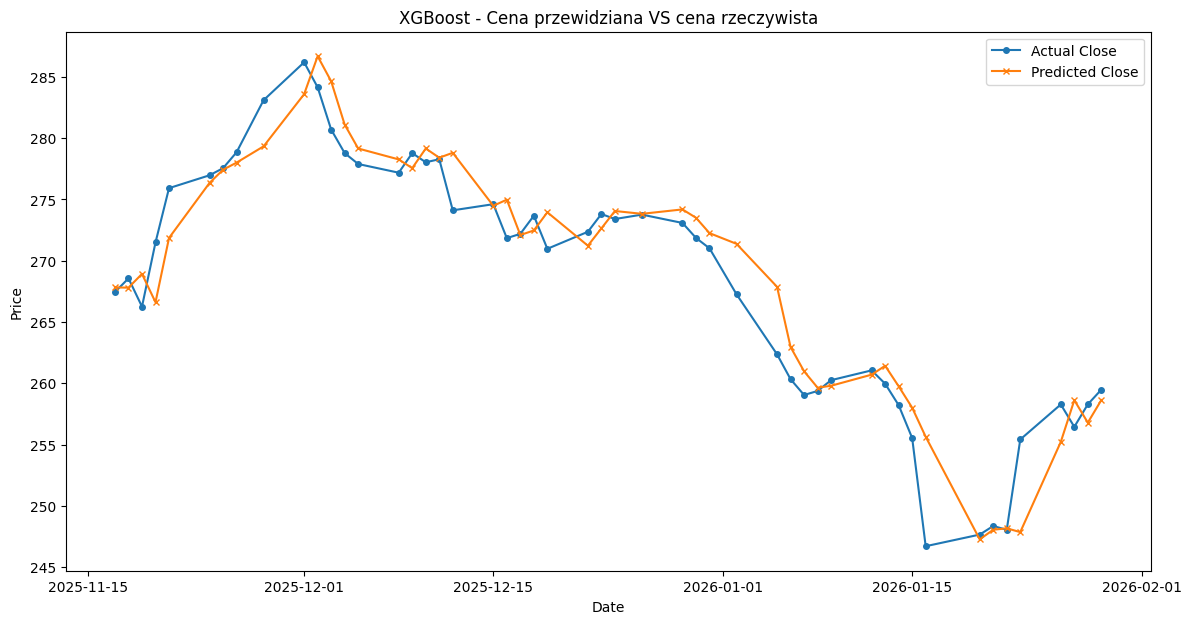

In [37]:
plotdf = prediction
plt.figure(figsize=(14,7))
plt.plot(plotdf.index[-50:], plotdf['Actual_Close'][-50:], label='Actual Close', marker='o', markersize=4)
plt.plot(plotdf.index[-50:], plotdf['Predicted_Close'][-50:], label='Predicted Close', marker='x', markersize=4)
plt.title('XGBoost - Cena przewidziana VS cena rzeczywista')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

### Metryki ewaluacyjne XGBoost

Obliczamy metryki dla XGBoost:
- **MAE** — Mean Absolute Error
- **RMSE** — Root Mean Squared Error
- **MAPE** — Mean Absolute Percentage Error
- **R²** — Coefficient of Determination

In [38]:

# Obliczanie metryk dla XGBoost
y_true_xgboost = prediction['Actual_Close'].values
y_pred_xgboost = prediction['Predicted_Close'].values

mae_xgboost = mean_absolute_error(y_true_xgboost, y_pred_xgboost)
rmse_xgboost = np.sqrt(mean_squared_error(y_true_xgboost, y_pred_xgboost))
mape_xgboost = np.mean(np.abs((y_true_xgboost - y_pred_xgboost) / y_true_xgboost)) * 100
r2_xgboost = r2_score(y_true_xgboost, y_pred_xgboost)

print("="*60)
print(" METRYKI EWALUACYJNE - XGBOOST")
print("="*60)
print(f"MAE (Mean Absolute Error):       ${mae_xgboost:.4f}")
print(f"RMSE (Root Mean Squared Error):  ${rmse_xgboost:.4f}")
print(f"MAPE (Mean Absolute % Error):    {mape_xgboost:.4f}%")
print(f"R² (Coefficient of Determination): {r2_xgboost:.4f}")
print("="*60)

 METRYKI EWALUACYJNE - XGBOOST
MAE (Mean Absolute Error):       $2.7007
RMSE (Root Mean Squared Error):  $4.0569
MAPE (Mean Absolute % Error):    1.1967%
R² (Coefficient of Determination): 0.9739


## Meta Prophet

### Czym jest Prophet?

**Meta Prophet** to biblioteka do prognozowania szeregów czasowych opracowana przez Facebook (Meta). Jest oparta na **addytywnym modelu regresyjnym** z następującymi komponentami:

$$y(t) = g(t) + s(t) + h(t) + \epsilon_t$$

gdzie:
- **g(t)** — trend (liniowy lub logistyczny)
- **s(t)** — sezonowość (roczna, tygodniowa, dzienna)
- **h(t)** — efekty dni świątecznych
- **ε(t)** — błąd

### Kluczowe zalety Prophet:
- **Automatyczna detekcja sezonowości** — identyfikuje wzorce roczne, miesięczne, tygodniowe
- **Odporność na braki danych** — radzi sobie z lukami w szeregu czasowym
- **Elastyczność** — pozwala na dodanie zewnętrznych regresorów (wskaźniki techniczne, makro)
- **Interpretowalne komponenty** — można wizualizować wkład trendu, sezonowości i regresorów
- **Obsługa punktów zwrotnych** — automatycznie wykrywa zmiany w trendzie


### Przygotowanie danych i modelowanie

W procesie trenowania modelu Prophet dla akcji AAPL przyjęto następującą strukturę danych:

*   **Regresory zewnętrzne:** EMA50, BB_PB, VXN, DXY.
*   **Target (Zmienna objaśniana):** `Diff_T1` — różnica dolarowa między kolejnymi dniami (differencing).

**Uzasadnienie doboru cech:**
*   **Brak `Close` jako regresora** — Prophet posiada wbudowany mechanizm modelowania trendu, dlatego bezpośrednie użycie ceny zamknięcia jako cechy jest zbędne.
*   **Różnicowanie (Differencing)** — Zamiast przewidywać surową cenę, model skupia się na zmianach dziennych (`Diff_T1`), co ułatwia wychwycenie lokalnych anomalii i wpływ regresorów zewnętrznych.
*   **Porównanie z XGBoost** — O ile w modelu XGBoost opóźnione wartości `Close` (lags) są kluczowe, o tyle Prophet lepiej radzi sobie z dekompozycją szeregu na komponenty przy użyciu wskaźników technicznych i rynkowych jako regresorów.

In [39]:
def create_prophet_model():
    
    # Krok 1: Prophet wymaga specjalnych nazw kolumn
    # 'ds' = data, 'y' = target
    prophet_data = data.reset_index().rename(columns={'Date': 'ds', 'Close': 'y'})
    
    # Krok 2: Obliczamy target - różnicę w dolarach zamiast samej ceny
    # shift(-1) przesuwa dane "w dół" żeby mieć jutrzejszą cenę
    # Diff_T1 = ile $ się zmieniła cena następnego dnia
    prophet_data['Diff_T1'] = prophet_data['y'].shift(-1) - prophet_data['y']
    
    # Zapisujemy też obecną i następną cenę - przyda się później do przeliczenia
    prophet_data['Curr_Close'] = prophet_data['y']  
    prophet_data['Next_Close'] = prophet_data['y'].shift(-1)
    
    # Krok 3: Dodajemy 4 cechy techniczne/makro jako dodatkowe zmienne
    # Prophet będzie ich używał razem ze swoim trendem i sezonowością
    prophet_data['EMA50'] = data['EMA50'].values
    prophet_data['BB_PB'] = data['BB_PB'].values  
    prophet_data['VXN'] = data['VXN'].values        
    prophet_data['DXY'] = data['DXY'].values      
    
    # Usuwamy wiersze gdzie jest NaN (na końcu przez shift)
    prophet_data = prophet_data.dropna()
    
    # Krok 4: Dzielimy dane na train i test
    # nie robimy shuffle! bo to szereg czasowy
    test_size_prophet = 0.05 # ostatnie 5% danych = test
    split_idx = int(len(prophet_data) * (1 - test_size_prophet))
    
    train_data_prophet = prophet_data.iloc[:split_idx].copy()
    test_data_prophet = prophet_data.iloc[split_idx:].copy()
    
    # Krok 5: Przygotowanie finalnej tabeli do treningu
    # Prophet oczekuje: ds (data) + y (target) + regresory
    train_prophet = train_data_prophet[[
        'ds', 'Diff_T1', 'EMA50', 'BB_PB', 'VXN', 'DXY'
    ]].rename(columns={'Diff_T1': 'y'})  # zmieniamy nazwę Diff_T1 na 'y'
    
    # Krok 6: Tworzymy model
    # daily_seasonality=False bo to dane dzienne (nie ma sensu dziennej sezonowości)
    # weekly/yearly=True bo może być efekt "poniedziałku" albo sezonowość w roku
    model = Prophet(
        daily_seasonality=False,
        weekly_seasonality=True,
        yearly_seasonality=True,
    )
    
    # Dodajemy nasze 4 cechy jako external regressors
    # Prophet sam policzy ich wpływ na target
    model.add_regressor('EMA50')
    model.add_regressor('BB_PB')
    model.add_regressor('VXN')
    model.add_regressor('DXY')
    
    # Trenujemy model
    model.fit(train_prophet)
    
    return model, test_data_prophet

In [40]:
def predict_prophet(model, test_data_prophet):
    """
    Robi predykcje na danych testowych i przelicza z różnic na ceny.
    
    Model przewiduje różnice dolarowe (ile $ zmieni się cena jutro),
    ale my chcemy mieć konkretną cenę, więc trzeba to przeliczyć:
    Predicted_Close = Current_Close + Predicted_Diff
    """
    
    # Krok 1: Przygotowanie danych do predykcji
    # Prophet.predict() wymaga ds (daty) + te same regresory co przy treningu
    test_prophet = test_data_prophet[[
        'ds', 'EMA50', 'BB_PB', 'VXN', 'DXY'
    ]].copy()
    
    # Krok 2: Robimy predykcję
    # forecast['yhat'] to nasza przewidziana różnica w $
    forecast = model.predict(test_prophet)
    
    # Krok 3: Bierzemy obecne i rzeczywiste ceny z danych testowych
    results = test_data_prophet[['ds', 'Curr_Close', 'Next_Close']].copy()
    
    # Krok 4: Przeliczamy różnicę $ na konkretną cenę
    # Logika: jeśli dzisiaj jest 100$ i model przewidział różnicę +5$, to jutro będzie 105$
    results['Predicted_Diff'] = forecast['yhat'].values  # przewidziana różnica
    results['Predicted_Close'] = results['Curr_Close'] + results['Predicted_Diff']  # obecna + różnica = przyszła
    
    # Dla porównania bierzemy też rzeczywistą cenę (Next_Close)
    results['Actual_Close'] = results['Next_Close']
    
    # Krok 5: Prophet daje też przedziały ufności (uncertainty)
    # yhat_lower i yhat_upper to dolna i górna granica przewidywania
    # też przeliczamy je z różnic na ceny
    results['yhat_lower'] = results['Curr_Close'] + forecast['yhat_lower'].values  # najniższa możliwa cena
    results['yhat_upper'] = results['Curr_Close'] + forecast['yhat_upper'].values  # najwyższa możliwa cena
    
    # Zwracamy tylko te kolumny które nas interesują
    return results[['ds', 'Actual_Close', 'Predicted_Close', 'yhat_lower', 'yhat_upper']]

In [41]:
# Wywołanie funkcji (analogicznie do XGBoost)
model_prophet, test_data_prophet = create_prophet_model()
results_prophet = predict_prophet(model_prophet, test_data_prophet)

results_prophet.tail(10)

11:51:59 - cmdstanpy - INFO - Chain [1] start processing
11:51:59 - cmdstanpy - INFO - Chain [1] done processing


,ds,Actual_Close,Predicted_Close,yhat_lower,yhat_upper
6282,2026-01-15,255.529999,258.237879,256.662203,259.757204
6283,2026-01-16,246.699997,255.586919,254.125214,257.190865
6284,2026-01-20,247.649994,246.784951,245.178360,248.287866
6285,2026-01-21,248.350006,247.689186,246.180917,249.290171
6286,2026-01-22,248.039993,248.442477,246.803476,250.177155
6287,2026-01-23,255.410004,248.160502,246.601776,249.711960
6288,2026-01-26,258.269989,255.562047,253.908863,257.124744
6289,2026-01-27,256.440002,258.391346,256.840939,259.892870
6290,2026-01-28,258.279999,256.509456,254.953629,258.118200
6291,2026-01-29,259.480011,258.394536,256.615101,259.977750


### Metryki ewaluacyjne Prophet

Obliczamy te same metryki co dla XGBoost:
- **MAE** — Mean Absolute Error
- **RMSE** — Root Mean Squared Error
- **MAPE** — Mean Absolute Percentage Error
- **R²** — Coefficient of Determination

In [42]:
# Obliczanie metryk
y_true_prophet = results_prophet['Actual_Close'].values
y_pred_prophet = results_prophet['Predicted_Close'].values

mae_prophet = mean_absolute_error(y_true_prophet, y_pred_prophet)
rmse_prophet = np.sqrt(mean_squared_error(y_true_prophet, y_pred_prophet))
mape_prophet = np.mean(np.abs((y_true_prophet - y_pred_prophet) / y_true_prophet)) * 100
r2_prophet = r2_score(y_true_prophet, y_pred_prophet)

print("="*60)
print(" METRYKI EWALUACYJNE - PROPHET")
print("="*60)
print(f"MAE (Mean Absolute Error):       ${mae_prophet:.4f}")
print(f"RMSE (Root Mean Squared Error):  ${rmse_prophet:.4f}")
print(f"MAPE (Mean Absolute % Error):    {mape_prophet:.4f}%")
print(f"R² (Coefficient of Determination): {r2_prophet:.4f}")
print("="*60)

 METRYKI EWALUACYJNE - PROPHET
MAE (Mean Absolute Error):       $2.6724
RMSE (Root Mean Squared Error):  $4.0153
MAPE (Mean Absolute % Error):    1.1831%
R² (Coefficient of Determination): 0.9741


### Wizualizacja wyników Prophet

Wykres porównujący rzeczywiste ceny z prognozami Prophet (w tym samym stylu co XGBoost).

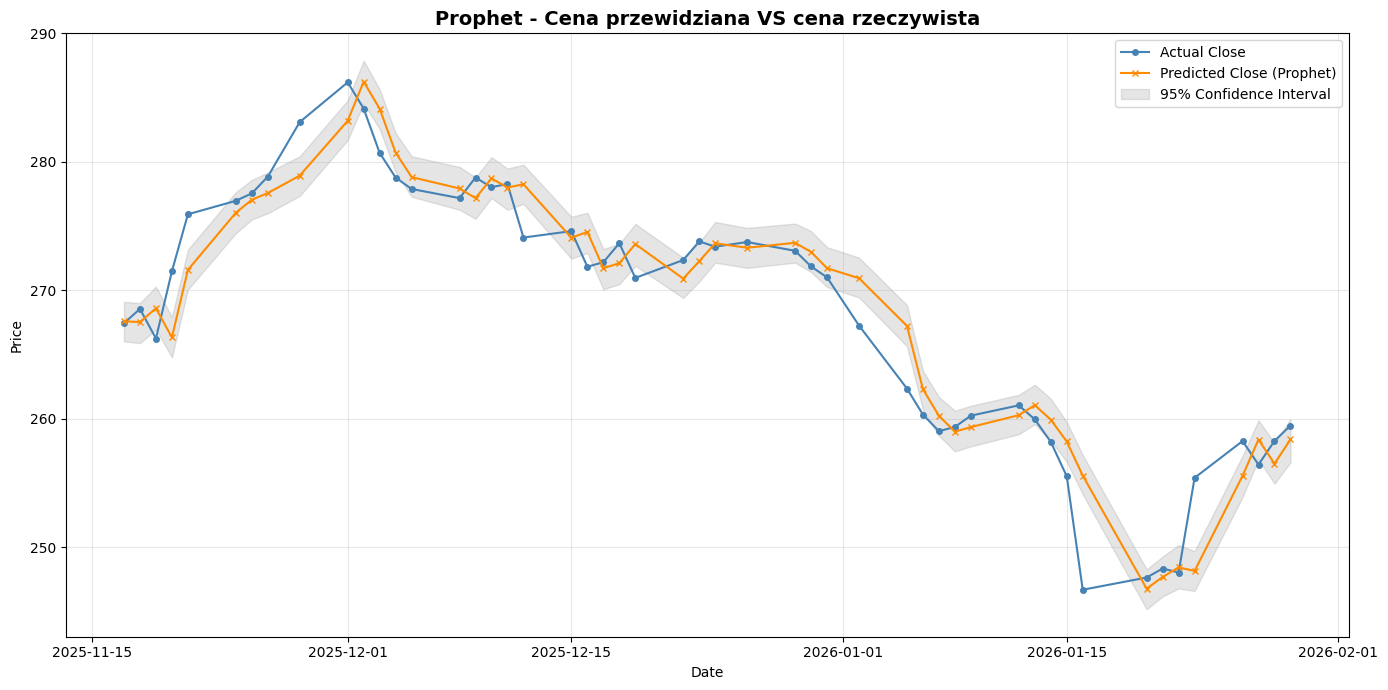

In [43]:
plotdf_prophet = results_prophet
plt.figure(figsize=(14, 7))
plt.plot(plotdf_prophet['ds'][-50:], plotdf_prophet['Actual_Close'][-50:], label='Actual Close', marker='o', markersize=4, color='steelblue')
plt.plot(plotdf_prophet['ds'][-50:], plotdf_prophet['Predicted_Close'][-50:], label='Predicted Close (Prophet)', marker='x', markersize=4, color='darkorange')

# Przedział ufności
plt.fill_between(plotdf_prophet['ds'][-50:], plotdf_prophet['yhat_lower'][-50:], plotdf_prophet['yhat_upper'][-50:], 
                 alpha=0.2, color='gray', label='95% Confidence Interval')

plt.title('Prophet - Cena przewidziana VS cena rzeczywista', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Porównanie wszystkich modeli

### Zestawienie metryk - LSTM vs XGBoost vs Prophet

Porównujemy skuteczność trzech różnych podejść do prognozowania szeregów czasowych:
- **LSTM** — Sieć neuronowa z pamięcią, sekwencje 60 dni
- **XGBoost** — Gradient Boosting, 100 lagów cech
- **Prophet** — Model addytywny z trendem i sezonowością

Wszystkie modele używają tego samego:
- **Differencing** (przewidywanie różnic $ zamiast cen)
- **Podział danych** (95% train / 5% test)
- **Bazy cech** (Close, EMA50, BB_PB, VXN, DXY)

In [44]:
# Tabela porównawcza metryk
comparison_df = pd.DataFrame({
    'Model': ['LSTM', 'XGBoost', 'Prophet'],
    'MAE ($)': [mae_lstm, mae_xgboost, mae_prophet],
    'RMSE ($)': [rmse_lstm, rmse_xgboost, rmse_prophet],
    'MAPE (%)': [mape_lstm, mape_xgboost, mape_prophet],
    'R²': [r2_lstm, r2_xgboost, r2_prophet]
})

# Formatowanie
comparison_df = comparison_df.round(4)

# Znalezienie najlepszych wartości (najniższe dla MAE/RMSE/MAPE, najwyższe dla R²)
best_mae = comparison_df['MAE ($)'].min()
best_rmse = comparison_df['RMSE ($)'].min()
best_mape = comparison_df['MAPE (%)'].min()
best_r2 = comparison_df['R²'].max()

print("="*70)
print(" PORÓWNANIE METRYK - WSZYSTKIE MODELE")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)

# Wyświetlenie najlepszych wyników
print("\n NAJLEPSZE WYNIKI:")
print(f"   MAE:  {comparison_df.loc[comparison_df['MAE ($)'] == best_mae, 'Model'].values[0]} = ${best_mae:.4f}")
print(f"   RMSE: {comparison_df.loc[comparison_df['RMSE ($)'] == best_rmse, 'Model'].values[0]} = ${best_rmse:.4f}")
print(f"   MAPE: {comparison_df.loc[comparison_df['MAPE (%)'] == best_mape, 'Model'].values[0]} = {best_mape:.4f}%")
print(f"   R²:   {comparison_df.loc[comparison_df['R²'] == best_r2, 'Model'].values[0]} = {best_r2:.4f}")
print("="*70)

comparison_df

 PORÓWNANIE METRYK - WSZYSTKIE MODELE
  Model  MAE ($)  RMSE ($)  MAPE (%)     R²
   LSTM   2.6984    4.0493    1.1945 0.9739
XGBoost   2.7007    4.0569    1.1967 0.9739
Prophet   2.6724    4.0153    1.1831 0.9741

 NAJLEPSZE WYNIKI:
   MAE:  Prophet = $2.6724
   RMSE: Prophet = $4.0153
   MAPE: Prophet = 1.1831%
   R²:   Prophet = 0.9741


,Model,MAE ($),RMSE ($),MAPE (%),R²
0,LSTM,2.6984,4.0493,1.1945,0.9739
1,XGBoost,2.7007,4.0569,1.1967,0.9739
2,Prophet,2.6724,4.0153,1.1831,0.9741


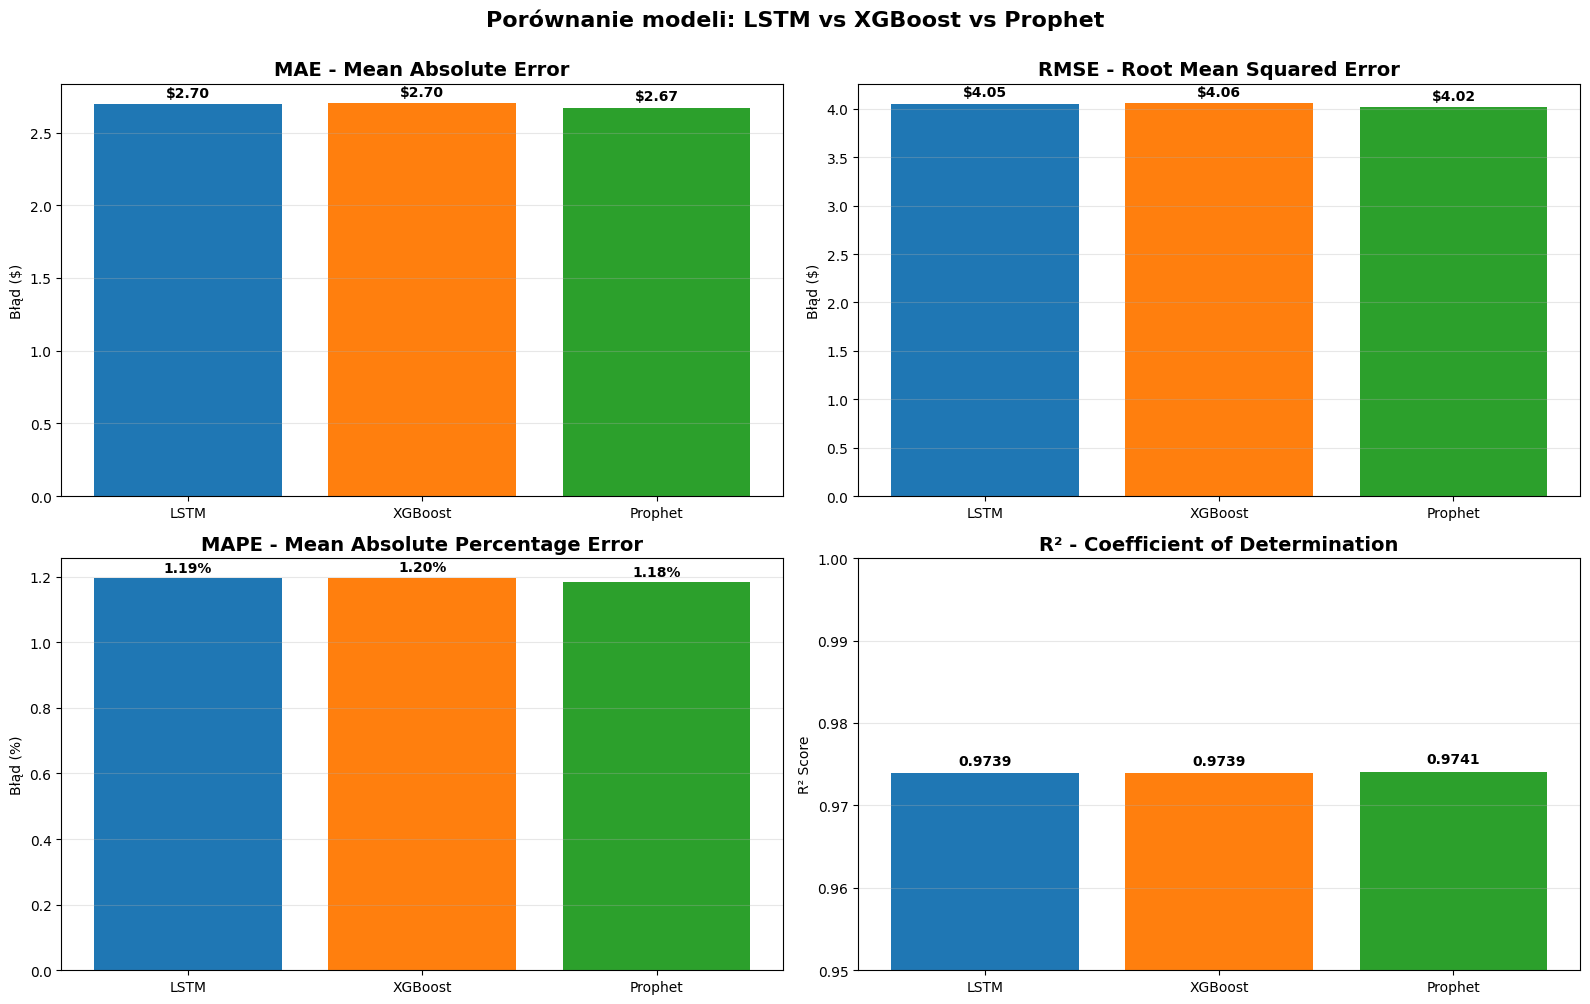


 Interpretacja:
   - Niższe MAE/RMSE/MAPE = lepszy model
   - Wyższe R² = lepszy model (1.0 = idealne dopasowanie)


In [45]:
# Wizualizacja porównania metryk - wykresy słupkowe
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# MAE
axes[0, 0].bar(comparison_df['Model'], comparison_df['MAE ($)'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0, 0].set_title('MAE - Mean Absolute Error', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Błąd ($)')
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_df['MAE ($)']):
    axes[0, 0].text(i, v + 0.05, f'${v:.2f}', ha='center', fontweight='bold')

# RMSE
axes[0, 1].bar(comparison_df['Model'], comparison_df['RMSE ($)'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0, 1].set_title('RMSE - Root Mean Squared Error', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Błąd ($)')
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_df['RMSE ($)']):
    axes[0, 1].text(i, v + 0.08, f'${v:.2f}', ha='center', fontweight='bold')

# MAPE
axes[1, 0].bar(comparison_df['Model'], comparison_df['MAPE (%)'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1, 0].set_title('MAPE - Mean Absolute Percentage Error', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Błąd (%)')
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_df['MAPE (%)']):
    axes[1, 0].text(i, v + 0.02, f'{v:.2f}%', ha='center', fontweight='bold')

# R²
axes[1, 1].bar(comparison_df['Model'], comparison_df['R²'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1, 1].set_title('R² - Coefficient of Determination', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('R² Score')
axes[1, 1].set_ylim([0.95, 1.0])  # Zoom do lepszej widoczności różnic
axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_df['R²']):
    axes[1, 1].text(i, v + 0.001, f'{v:.4f}', ha='center', fontweight='bold')

plt.suptitle('Porównanie modeli: LSTM vs XGBoost vs Prophet', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\n Interpretacja:")
print("   - Niższe MAE/RMSE/MAPE = lepszy model")
print("   - Wyższe R² = lepszy model (1.0 = idealne dopasowanie)")

### Porównanie predykcji na tym samym wykresie

Wizualizacja rzeczywistych cen vs predykcje wszystkich trzech modeli na zbiorze testowym.

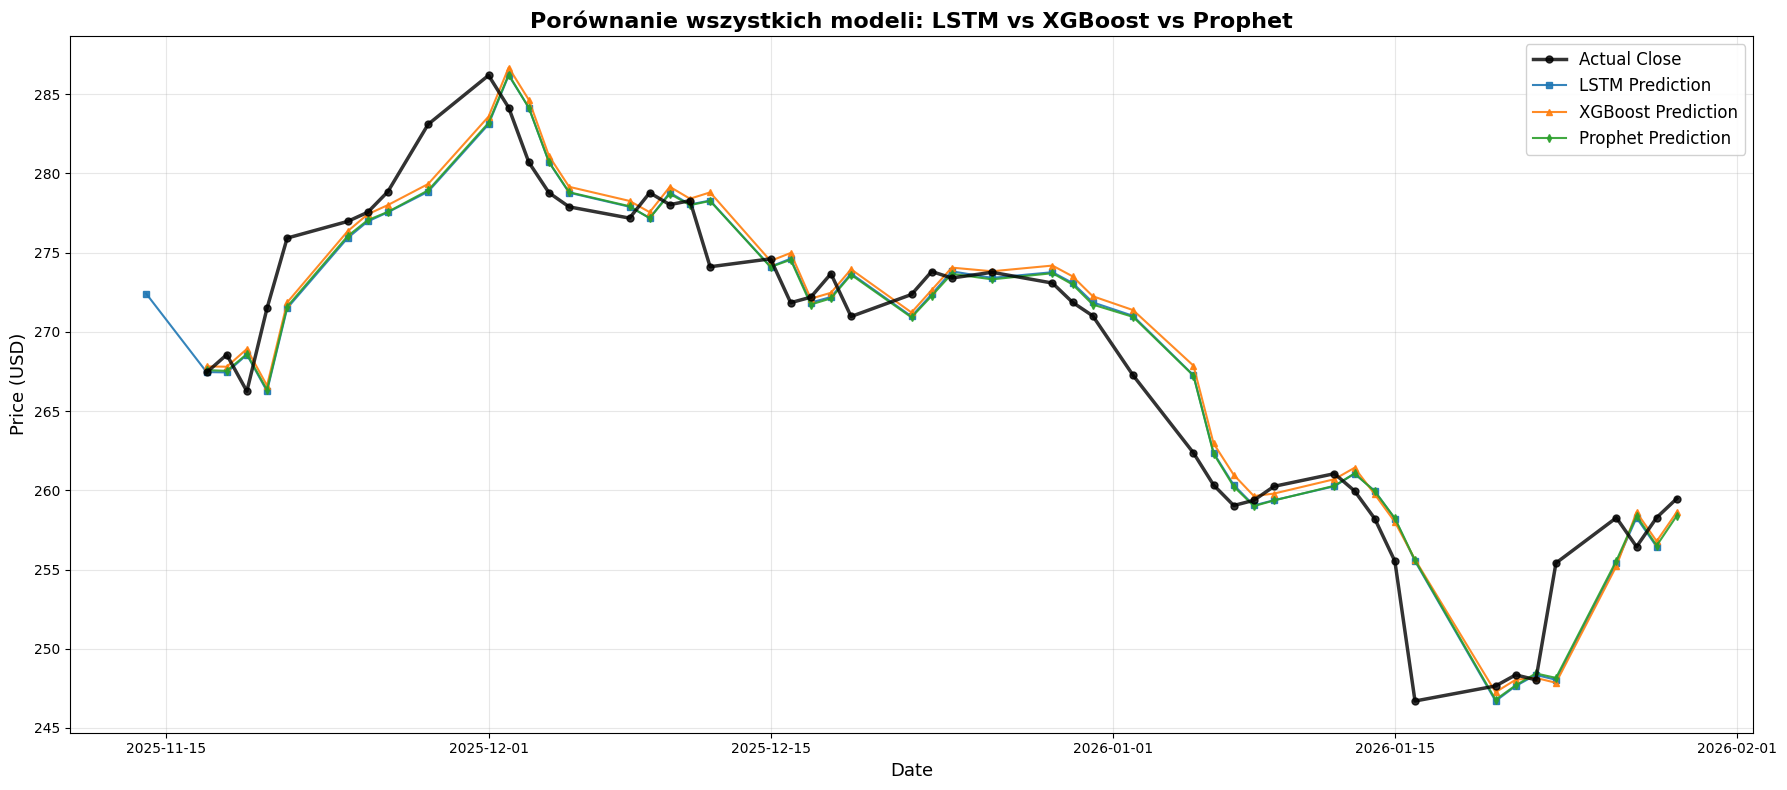


 Porównanie na 310 dniach testowych:
   LSTM    - MAE: $2.70, RMSE: $4.05, R²: 0.9739
   XGBoost - MAE: $2.70, RMSE: $4.06, R²: 0.9739
   Prophet - MAE: $2.67, RMSE: $4.02, R²: 0.9741


In [46]:
# Porównanie wszystkich modeli na jednym wykresie
plt.figure(figsize=(18, 8))

# Rzeczywiste ceny (wspólne dla wszystkich)
plt.plot(prediction.index[-50:], prediction['Actual_Close'][-50:], 
         label='Actual Close', marker='o', markersize=5, 
         color='black', linewidth=2.5, alpha=0.8, zorder=5)

# Predykcje LSTM
plt.plot(results_lstm['Date'][-50:], results_lstm['Predicted_Close'][-50:], 
         label='LSTM Prediction', marker='s', markersize=4, 
         color='#1f77b4', linewidth=1.5, alpha=0.9)

# Predykcje XGBoost
plt.plot(prediction.index[-50:], prediction['Predicted_Close'][-50:], 
         label='XGBoost Prediction', marker='^', markersize=4, 
         color='#ff7f0e', linewidth=1.5, alpha=0.9)

# Predykcje Prophet
plt.plot(results_prophet['ds'][-50:], results_prophet['Predicted_Close'][-50:], 
         label='Prophet Prediction', marker='d', markersize=4, 
         color='#2ca02c', linewidth=1.5, alpha=0.9)

plt.title('Porównanie wszystkich modeli: LSTM vs XGBoost vs Prophet', 
          fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=13)
plt.ylabel('Price (USD)', fontsize=13)
plt.legend(loc='best', fontsize=12, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n Porównanie na {len(prediction)} dniach testowych:")
print(f"   LSTM    - MAE: ${mae_lstm:.2f}, RMSE: ${rmse_lstm:.2f}, R²: {r2_lstm:.4f}")
print(f"   XGBoost - MAE: ${mae_xgboost:.2f}, RMSE: ${rmse_xgboost:.2f}, R²: {r2_xgboost:.4f}")
print(f"   Prophet - MAE: ${mae_prophet:.2f}, RMSE: ${rmse_prophet:.2f}, R²: {r2_prophet:.4f}")


## Modele - GRU, Random Forest, SVR

### Dalsza nalizy

Do trzech głównych modeli (LSTM, XGBoost, Prophet) dodajemy trzy dodatkowe podejścia:

| Model | Typ | Uzasadnienie wyboru |
| :--- | :--- | :--- |
| **GRU** | Deep Learning (Recurrent) | Szybszy trening niż LSTM, efektywny na mniejszych zbiorach |
| **Random Forest** | Ensemble (Bagging) | Kontrast z XGBoost (Boosting), mniejsza podatność na overfitting |
| **SVR** | Classical ML (Geometric) | Efektywny w wysokowymiarowych przestrzeniach, odporny na outliers |

Wszystkie modele używają:
- **Tych samych sygnałów**: Close, EMA50, BB_PB, VXN, DXY
- **Tego samego targetu**: Diff_T1 (różnica dolarowa)
- **Tego samego podziału**: 95% train / 5% test

## GRU (Gated Recurrent Unit)

### Architektura

GRU to uproszczona wersja LSTM z dwoma bramkami zamiast trzech:
- **Update gate** — kontroluje jak dużo poprzedniego stanu zachować
- **Reset gate** — decyduje jak dużo poprzedniego stanu zapomnieć

$$z_t = \sigma(W_z \cdot [h_{t-1}, x_t])$$
$$r_t = \sigma(W_r \cdot [h_{t-1}, x_t])$$
$$\tilde{h}_t = \tanh(W \cdot [r_t \odot h_{t-1}, x_t])$$
$$h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$$

**Zalety vs LSTM:**
- Mniej parametrów = szybszy trening
- Lepsza wydajność na mniejszych zbiorach danych
- Porównywalna skuteczność w wielu zastosowaniach

In [11]:
# Implementacja GRU
from tensorflow.keras.layers import GRU

def create_gru_model(lookback: int = 60):
    """
    Tworzy i trenuje model GRU do predykcji różnic cen.
    Analogiczna struktura do LSTM dla porównywalności wyników.
    """
    gru_data = data.copy()

    # Target: różnica dolarowa (identycznie jak w LSTM)
    gru_data['Diff_T1'] = gru_data['Close'].shift(-1) - gru_data['Close']
    gru_data = gru_data.dropna()

    # Skalowanie
    scaler_features = MinMaxScaler()
    scaler_target = MinMaxScaler()

    features_cols = ['Close', 'EMA50', 'BB_PB', 'VXN', 'DXY']
    scaled_features = scaler_features.fit_transform(gru_data[features_cols])
    scaled_target = scaler_target.fit_transform(gru_data[['Diff_T1']])

    # Tworzenie sekwencji 3D: [samples, timesteps, features]
    X, y = [], []
    for i in range(lookback, len(scaled_features)):
        X.append(scaled_features[i - lookback:i])
        y.append(scaled_target[i])

    X = np.array(X)
    y = np.array(y)

    print(f"   Sekwencje GRU: X shape = {X.shape}, y shape = {y.shape}")

    # Podział train/test (bez shuffle)
    split_idx = int(len(X) * 0.95)
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    print(f"   Train: {len(X_train)} sekwencji")
    print(f"   Test:  {len(X_test)} sekwencji")

    # Architektura GRU: 2 warstwy + Dropout (jak w specyfikacji)
    model = Sequential([
        GRU(50, return_sequences=True, input_shape=(lookback, len(features_cols))),
        Dropout(0.2),
        GRU(50, return_sequences=False),
        Dropout(0.2),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=1
    )

    return model, X_test, y_test, scaler_features, scaler_target, gru_data.iloc[split_idx + lookback:]


def predict_gru(model, X_test, scaler_features, scaler_target, test_data_original):
    """Generuje predykcje GRU i przelicza różnice na ceny."""
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred_diff = scaler_target.inverse_transform(y_pred_scaled).flatten()

    results = pd.DataFrame({
        'Date': test_data_original.index,
        'Curr_Close': test_data_original['Close'].values,
        'Next_Close': test_data_original['Close'].shift(-1).values,
    })

    results['Predicted_Diff'] = y_pred_diff
    results['Predicted_Close'] = results['Curr_Close'] + results['Predicted_Diff']
    results['Actual_Close'] = results['Next_Close']
    results = results.dropna()

    return results[['Date', 'Actual_Close', 'Predicted_Close']]

In [12]:
# Trenowanie GRU
model_gru, X_test_gru, y_test_gru, scaler_feat_gru, scaler_targ_gru, test_data_gru = create_gru_model(lookback=60)

   Sekwencje GRU: X shape = (6232, 60, 5), y shape = (6232, 1)
   Train: 5920 sekwencji
   Test:  312 sekwencji
Epoch 1/50


E0000 00:00:1769942559.293577   15211 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1769942559.299523   15211 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


167/167 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0127 - mae: 0.0755 - val_loss: 0.0037 - val_mae: 0.0457
Epoch 2/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0023 - mae: 0.0371 - val_loss: 0.0037 - val_mae: 0.0461
Epoch 3/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0018 - mae: 0.0323 - val_loss: 0.0039 - val_mae: 0.0473
Epoch 4/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0016 - mae: 0.0299 - val_loss: 0.0039 - val_mae: 0.0471
Epoch 5/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0014 - mae: 0.0287 - val_loss: 0.0046 - val_mae: 0.0525
Epoch 6/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0014 - mae: 0.0280 - val_loss: 0.0040 - val_mae: 0.0479
Epoch 7/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0012 - mae: 0.0259 - val_loss: 0.0042 - val_mae: 0.0498
Epoch 8/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0011 - mae: 0.0250 - val_loss: 0.0035 - val_mae: 0.0446
Epoch 9/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss

In [13]:
# Predykcje GRU
results_gru = predict_gru(model_gru, X_test_gru, scaler_feat_gru, scaler_targ_gru, test_data_gru)
results_gru.tail(10)

,Date,Actual_Close,Predicted_Close
301,2026-01-14,258.209991,259.912088
302,2026-01-15,255.529999,258.161603
303,2026-01-16,246.699997,255.482077
304,2026-01-20,247.649994,246.651900
305,2026-01-21,248.350006,247.593157
306,2026-01-22,248.039993,248.293562
307,2026-01-23,255.410004,247.987532
308,2026-01-26,258.269989,255.359736
309,2026-01-27,256.440002,258.223687
310,2026-01-28,258.279999,256.397047


### Metryki ewaluacyjne GRU

In [14]:
# Metryki GRU
y_true_gru = results_gru['Actual_Close'].values
y_pred_gru = results_gru['Predicted_Close'].values

mae_gru = mean_absolute_error(y_true_gru, y_pred_gru)
rmse_gru = np.sqrt(mean_squared_error(y_true_gru, y_pred_gru))
mape_gru = np.mean(np.abs((y_true_gru - y_pred_gru) / y_true_gru)) * 100
r2_gru = r2_score(y_true_gru, y_pred_gru)

print("=" * 60)
print(" METRYKI EWALUACYJNE - GRU")
print("=" * 60)
print(f"MAE (Mean Absolute Error):       ${mae_gru:.4f}")
print(f"RMSE (Root Mean Squared Error):  ${rmse_gru:.4f}")
print(f"MAPE (Mean Absolute % Error):    {mape_gru:.4f}%")
print(f"R² (Coefficient of Determination): {r2_gru:.4f}")
print("=" * 60)

 METRYKI EWALUACYJNE - GRU
MAE (Mean Absolute Error):       $2.7007
RMSE (Root Mean Squared Error):  $4.0515
MAPE (Mean Absolute % Error):    1.1955%
R² (Coefficient of Determination): 0.9739


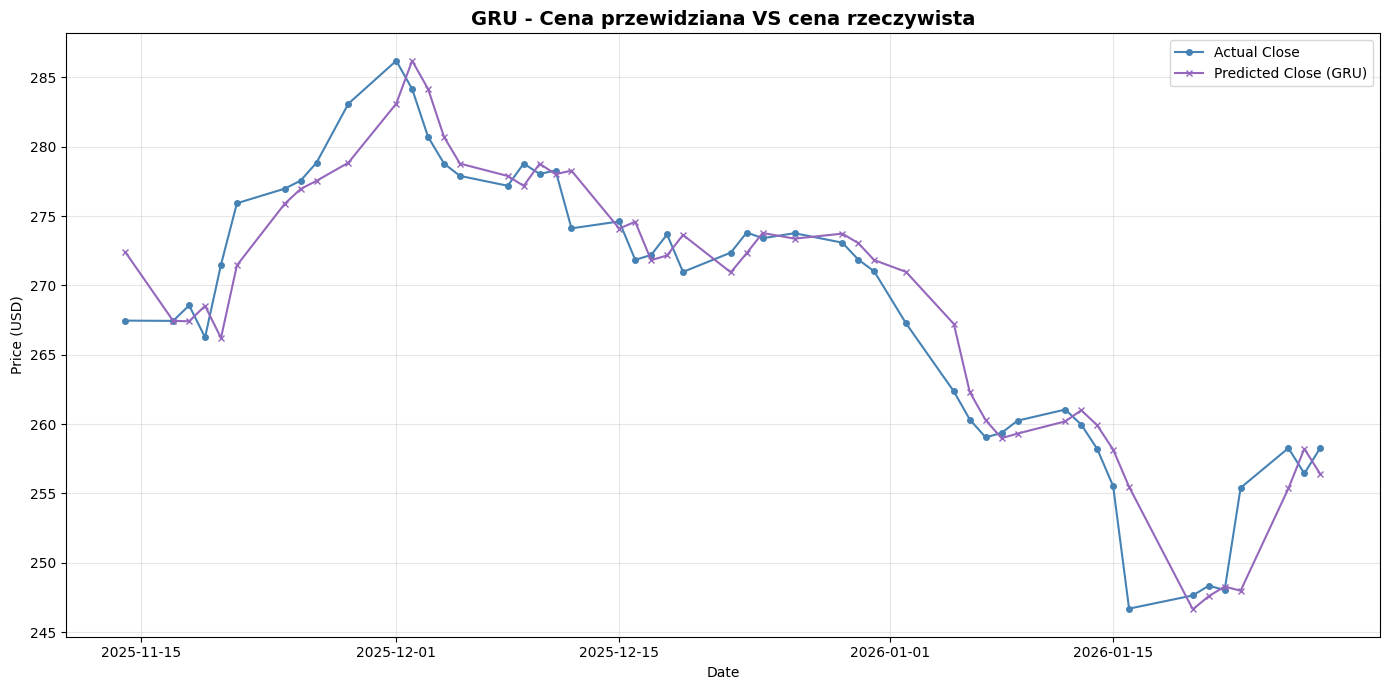

In [15]:
# Wizualizacja GRU
plt.figure(figsize=(14, 7))
plt.plot(results_gru['Date'][-50:], results_gru['Actual_Close'][-50:],
         label='Actual Close', marker='o', markersize=4, color='steelblue')
plt.plot(results_gru['Date'][-50:], results_gru['Predicted_Close'][-50:],
         label='Predicted Close (GRU)', marker='x', markersize=4, color='#9467bd')

plt.title('GRU - Cena przewidziana VS cena rzeczywista', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Random Forest Regressor

### Podejście Bagging vs Boosting

**Random Forest** używa **bagging** (Bootstrap Aggregating):
- Trenuje wiele niezależnych drzew na różnych podpróbkach danych
- Końcowa predykcja = średnia predykcji wszystkich drzew
- Redukuje wariancję, chroni przed overfittingiem

**XGBoost** (już w projekcie) używa **boosting**:
- Trenuje drzewa sekwencyjnie, każde poprawia błędy poprzednich
- Redukuje bias, ale może overfitować

**Parametry:**
- `n_estimators=100` — liczba drzew w lesie
- `max_depth=20` — maksymalna głębokość drzewa
- `random_state=42` — reprodukowalność

In [16]:
# Implementacja Random Forest
from sklearn.ensemble import RandomForestRegressor

def create_random_forest_model(lag: int = 60):
    """
    Tworzy i trenuje model Random Forest.
    Używa lagów podobnie jak XGBoost dla porównywalności.
    """
    rf_data = data.copy()

    # Target: różnica dolarowa
    rf_data['Diff_T1'] = rf_data['Close'].shift(-1) - rf_data['Close']

    # Tworzenie lagów
    lagged_cols = ['Close', 'EMA50', 'BB_PB', 'VXN', 'DXY']
    for col in lagged_cols:
        for l in range(1, lag + 1):
            rf_data[f'{col}_lag_{l}'] = rf_data[col].shift(l)

    rf_data = rf_data.dropna()

    # Features (bez Close i Diff_T1)
    feature_cols = [c for c in rf_data.columns if c not in ['Close', 'Diff_T1']]

    X = rf_data[feature_cols]
    y = rf_data['Diff_T1']

    print(f"   Random Forest features: {len(feature_cols)} kolumn")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.05, shuffle=False
    )

    print(f"   Train: {len(X_train)} próbek")
    print(f"   Test:  {len(X_test)} próbek")

    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=20,
        random_state=42,
        n_jobs=-1,
    )

    model.fit(X_train, y_train)

    return model, X_test, y_test


def predict_random_forest(model, X_test):
    """Generuje predykcje Random Forest i przelicza różnice na ceny."""
    y_pred_diff = model.predict(X_test)

    results = pd.DataFrame(index=X_test.index)
    results['Curr_Close'] = data['Close'].loc[X_test.index]
    results['Actual_Close'] = data['Close'].shift(-1).loc[X_test.index]
    results['Predicted_Diff'] = y_pred_diff
    results['Predicted_Close'] = results['Curr_Close'] + results['Predicted_Diff']

    results = results.dropna()

    return results[['Actual_Close', 'Predicted_Close']]

In [17]:
# Trenowanie Random Forest
model_rf, X_test_rf, y_test_rf = create_random_forest_model(lag=60)

   Random Forest features: 304 kolumn
   Train: 5920 próbek
   Test:  312 próbek


In [18]:
# Predykcje Random Forest
results_rf = predict_random_forest(model_rf, X_test_rf)
results_rf.tail(10)

,Actual_Close,Predicted_Close
Date,,
2026-01-15,255.529999,255.458208
2026-01-16,246.699997,252.747220
2026-01-20,247.649994,243.911040
2026-01-21,248.350006,244.946940
2026-01-22,248.039993,245.572812
2026-01-23,255.410004,245.055435
2026-01-26,258.269989,252.611494
2026-01-27,256.440002,255.389786
2026-01-28,258.279999,253.565736


### Metryki ewaluacyjne Random Forest

In [19]:
# Metryki Random Forest
y_true_rf = results_rf['Actual_Close'].values
y_pred_rf = results_rf['Predicted_Close'].values

mae_rf = mean_absolute_error(y_true_rf, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_true_rf, y_pred_rf))
mape_rf = np.mean(np.abs((y_true_rf - y_pred_rf) / y_true_rf)) * 100
r2_rf = r2_score(y_true_rf, y_pred_rf)

print("=" * 60)
print(" METRYKI EWALUACYJNE - RANDOM FOREST")
print("=" * 60)
print(f"MAE (Mean Absolute Error):       ${mae_rf:.4f}")
print(f"RMSE (Root Mean Squared Error):  ${rmse_rf:.4f}")
print(f"MAPE (Mean Absolute % Error):    {mape_rf:.4f}%")
print(f"R² (Coefficient of Determination): {r2_rf:.4f}")
print("=" * 60)

 METRYKI EWALUACYJNE - RANDOM FOREST
MAE (Mean Absolute Error):       $3.2846
RMSE (Root Mean Squared Error):  $4.5201
MAPE (Mean Absolute % Error):    1.4256%
R² (Coefficient of Determination): 0.9675


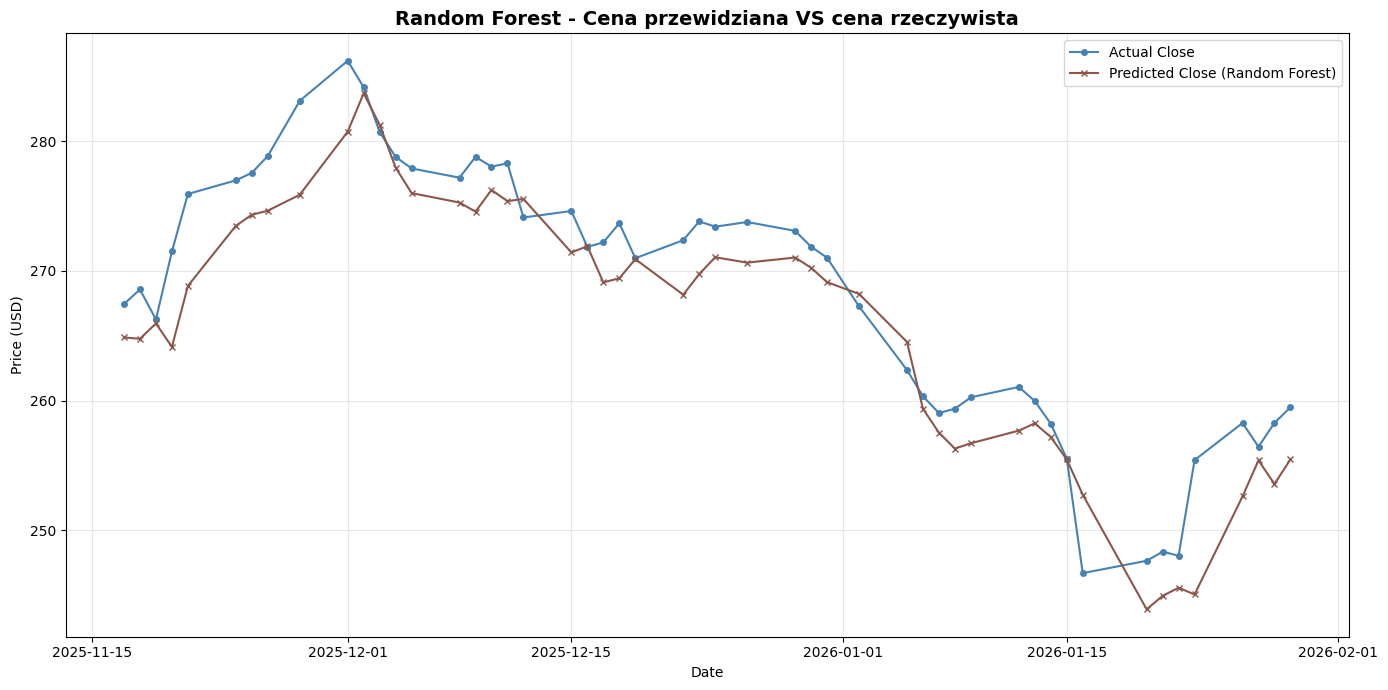

In [20]:
# Wizualizacja Random Forest
plt.figure(figsize=(14, 7))
plt.plot(results_rf.index[-50:], results_rf['Actual_Close'][-50:],
         label='Actual Close', marker='o', markersize=4, color='steelblue')
plt.plot(results_rf.index[-50:], results_rf['Predicted_Close'][-50:],
         label='Predicted Close (Random Forest)', marker='x', markersize=4, color='#8c564b')

plt.title('Random Forest - Cena przewidziana VS cena rzeczywista', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## SVR (Support Vector Regression)

### Podejście geometryczne

SVR szuka hiperpłaszczyzny w przestrzeni cech, która:
- Mieści się w **epsilon-tube** (margines tolerancji)
- Minimalizuje błąd dla punktów poza tym marginesem

**Kernel RBF** (Radial Basis Function):
$$K(x, x') = \exp(-\gamma ||x - x'||^2)$$

**Parametry:**
- `kernel='rbf'` — nieliniowy kernel Gaussowski
- `C=100` — parametr regularyzacji (większy = mniejszy margines)
- `gamma=0.1` — szerokość kernela RBF
- `epsilon=0.1` — szerokość epsilon-tube

**Uwaga:** SVR wymaga skalowanych danych!

In [21]:
# Implementacja SVR
from sklearn.svm import SVR

def create_svr_model(lag: int = 60):
    """
    Tworzy i trenuje model SVR.
    SVR wymaga skalowania wszystkich cech!
    """
    svr_data = data.copy()

    # Target: różnica dolarowa
    svr_data['Diff_T1'] = svr_data['Close'].shift(-1) - svr_data['Close']

    # Tworzenie lagów
    lagged_cols = ['Close', 'EMA50', 'BB_PB', 'VXN', 'DXY']
    for col in lagged_cols:
        for l in range(1, lag + 1):
            svr_data[f'{col}_lag_{l}'] = svr_data[col].shift(l)

    svr_data = svr_data.dropna()

    feature_cols = [c for c in svr_data.columns if c not in ['Close', 'Diff_T1']]

    X = svr_data[feature_cols]
    y = svr_data['Diff_T1']

    print(f"   SVR features: {len(feature_cols)} kolumn")

    # SVR wymaga skalowania!
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_scaled = pd.DataFrame(
        scaler_X.fit_transform(X),
        index=X.index,
        columns=X.columns
    )
    y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)).flatten()
    y_scaled = pd.Series(y_scaled, index=y.index)

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_scaled, test_size=0.05, shuffle=False
    )

    print(f"   Train: {len(X_train)} próbek")
    print(f"   Test:  {len(X_test)} próbek")

    model = SVR(
        kernel='rbf',
        C=100,
        gamma=0.1,
        epsilon=0.1,
    )

    model.fit(X_train, y_train)

    return model, X_test, y_test, scaler_X, scaler_y


def predict_svr(model, X_test, scaler_y):
    """Generuje predykcje SVR i przelicza różnice na ceny."""
    y_pred_scaled = model.predict(X_test)
    y_pred_diff = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

    results = pd.DataFrame(index=X_test.index)
    results['Curr_Close'] = data['Close'].loc[X_test.index]
    results['Actual_Close'] = data['Close'].shift(-1).loc[X_test.index]
    results['Predicted_Diff'] = y_pred_diff
    results['Predicted_Close'] = results['Curr_Close'] + results['Predicted_Diff']

    results = results.dropna()

    return results[['Actual_Close', 'Predicted_Close']]

In [22]:
# Trenowanie SVR
model_svr, X_test_svr, y_test_svr, scaler_X_svr, scaler_y_svr = create_svr_model(lag=60)

   SVR features: 304 kolumn
   Train: 5920 próbek
   Test:  312 próbek


In [23]:
# Predykcje SVR
results_svr = predict_svr(model_svr, X_test_svr, scaler_y_svr)
results_svr.tail(10)

,Actual_Close,Predicted_Close
Date,,
2026-01-15,255.529999,259.432118
2026-01-16,246.699997,256.876900
2026-01-20,247.649994,248.753531
2026-01-21,248.350006,249.959954
2026-01-22,248.039993,250.519739
2026-01-23,255.410004,250.046858
2026-01-26,258.269989,257.281619
2026-01-27,256.440002,259.759775
2026-01-28,258.279999,257.823174


### Metryki ewaluacyjne SVR

In [24]:
# Metryki SVR
y_true_svr = results_svr['Actual_Close'].values
y_pred_svr_vals = results_svr['Predicted_Close'].values

mae_svr = mean_absolute_error(y_true_svr, y_pred_svr_vals)
rmse_svr = np.sqrt(mean_squared_error(y_true_svr, y_pred_svr_vals))
mape_svr = np.mean(np.abs((y_true_svr - y_pred_svr_vals) / y_true_svr)) * 100
r2_svr = r2_score(y_true_svr, y_pred_svr_vals)

print("=" * 60)
print(" METRYKI EWALUACYJNE - SVR")
print("=" * 60)
print(f"MAE (Mean Absolute Error):       ${mae_svr:.4f}")
print(f"RMSE (Root Mean Squared Error):  ${rmse_svr:.4f}")
print(f"MAPE (Mean Absolute % Error):    {mape_svr:.4f}%")
print(f"R² (Coefficient of Determination): {r2_svr:.4f}")
print("=" * 60)

 METRYKI EWALUACYJNE - SVR
MAE (Mean Absolute Error):       $3.2122
RMSE (Root Mean Squared Error):  $4.4908
MAPE (Mean Absolute % Error):    1.4150%
R² (Coefficient of Determination): 0.9679


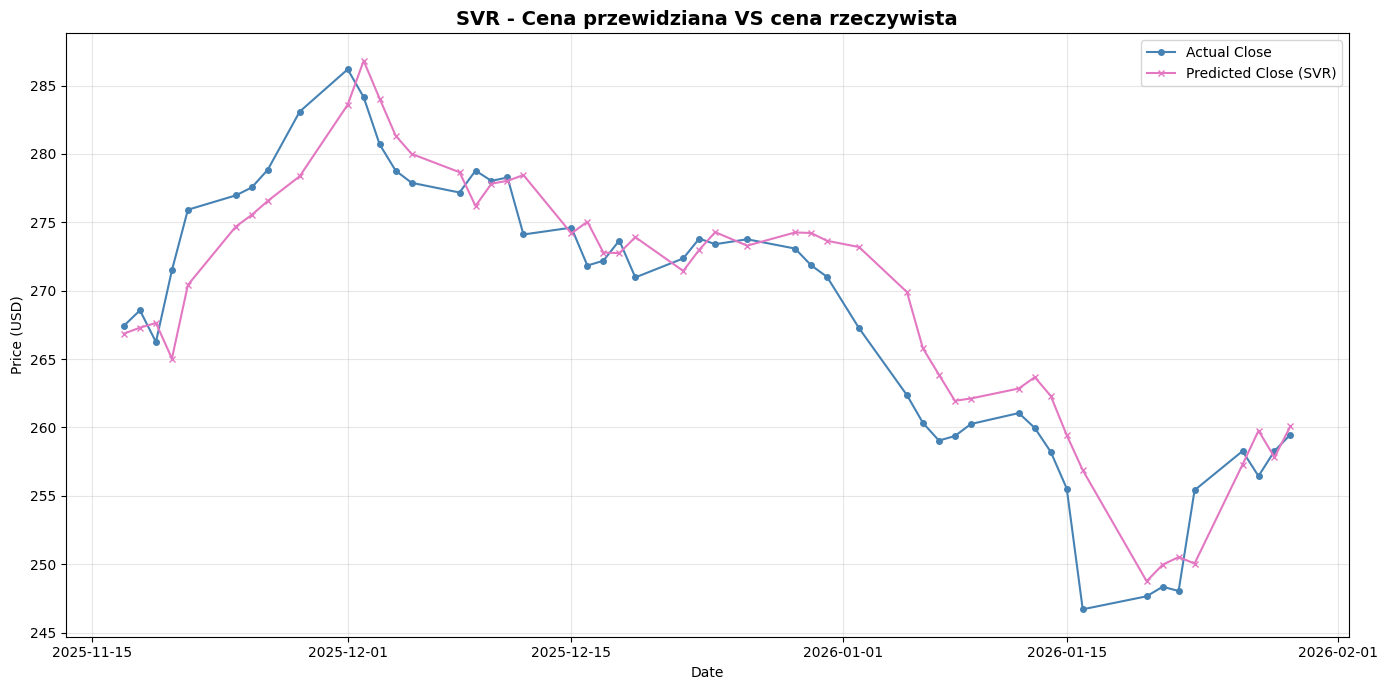

In [25]:
# Wizualizacja SVR
plt.figure(figsize=(14, 7))
plt.plot(results_svr.index[-50:], results_svr['Actual_Close'][-50:],
         label='Actual Close', marker='o', markersize=4, color='steelblue')
plt.plot(results_svr.index[-50:], results_svr['Predicted_Close'][-50:],
         label='Predicted Close (SVR)', marker='x', markersize=4, color='#e377c2')

plt.title('SVR - Cena przewidziana VS cena rzeczywista', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Porównanie wszystkich 6 modeli

### Zestawienie metryk - LSTM vs XGBoost vs Prophet vs GRU vs Random Forest vs SVR

Porównujemy skuteczność sześciu różnych podejść do prognozowania szeregów czasowych:

| Kategoria | Modele | Charakterystyka |
| :--- | :--- | :--- |
| **Deep Learning (RNN)** | LSTM, GRU | Modelowanie sekwencji, pamięć długoterminowa |
| **Ensemble** | XGBoost, Random Forest | Boosting vs Bagging, dobre na danych tabelarycznych |
| **Statistical** | Prophet | Dekompozycja trend/sezonowość |
| **Classical ML** | SVR | Podejście geometryczne, odporny na outliers |

In [47]:
# Tabela porównawcza wszystkich 6 modeli
comparison_all_df = pd.DataFrame({
    'Model': ['LSTM', 'XGBoost', 'Prophet', 'GRU', 'RandomForest', 'SVR'],
    'MAE ($)': [mae_lstm, mae_xgboost, mae_prophet, mae_gru, mae_rf, mae_svr],
    'RMSE ($)': [rmse_lstm, rmse_xgboost, rmse_prophet, rmse_gru, rmse_rf, rmse_svr],
    'MAPE (%)': [mape_lstm, mape_xgboost, mape_prophet, mape_gru, mape_rf, mape_svr],
    'R²': [r2_lstm, r2_xgboost, r2_prophet, r2_gru, r2_rf, r2_svr]
})

comparison_all_df = comparison_all_df.round(4)

# Najlepsze wyniki
best_mae = comparison_all_df['MAE ($)'].min()
best_rmse = comparison_all_df['RMSE ($)'].min()
best_mape = comparison_all_df['MAPE (%)'].min()
best_r2 = comparison_all_df['R²'].max()

print("=" * 80)
print(" PORÓWNANIE METRYK - WSZYSTKIE 6 MODELI")
print("=" * 80)
print(comparison_all_df.to_string(index=False))
print("=" * 80)

print("\n NAJLEPSZE WYNIKI:")
print(f"   MAE:  {comparison_all_df.loc[comparison_all_df['MAE ($)'] == best_mae, 'Model'].values[0]} = ${best_mae:.4f}")
print(f"   RMSE: {comparison_all_df.loc[comparison_all_df['RMSE ($)'] == best_rmse, 'Model'].values[0]} = ${best_rmse:.4f}")
print(f"   MAPE: {comparison_all_df.loc[comparison_all_df['MAPE (%)'] == best_mape, 'Model'].values[0]} = {best_mape:.4f}%")
print(f"   R²:   {comparison_all_df.loc[comparison_all_df['R²'] == best_r2, 'Model'].values[0]} = {best_r2:.4f}")
print("=" * 80)

comparison_all_df

 PORÓWNANIE METRYK - WSZYSTKIE 6 MODELI
       Model  MAE ($)  RMSE ($)  MAPE (%)     R²
        LSTM   2.6984    4.0493    1.1945 0.9739
     XGBoost   2.7007    4.0569    1.1967 0.9739
     Prophet   2.6724    4.0153    1.1831 0.9741
         GRU   2.7007    4.0515    1.1955 0.9739
RandomForest   3.2846    4.5201    1.4256 0.9675
         SVR   3.2122    4.4908    1.4150 0.9679

 NAJLEPSZE WYNIKI:
   MAE:  Prophet = $2.6724
   RMSE: Prophet = $4.0153
   MAPE: Prophet = 1.1831%
   R²:   Prophet = 0.9741


,Model,MAE ($),RMSE ($),MAPE (%),R²
0,LSTM,2.6984,4.0493,1.1945,0.9739
1,XGBoost,2.7007,4.0569,1.1967,0.9739
2,Prophet,2.6724,4.0153,1.1831,0.9741
3,GRU,2.7007,4.0515,1.1955,0.9739
4,RandomForest,3.2846,4.5201,1.4256,0.9675
5,SVR,3.2122,4.4908,1.4150,0.9679


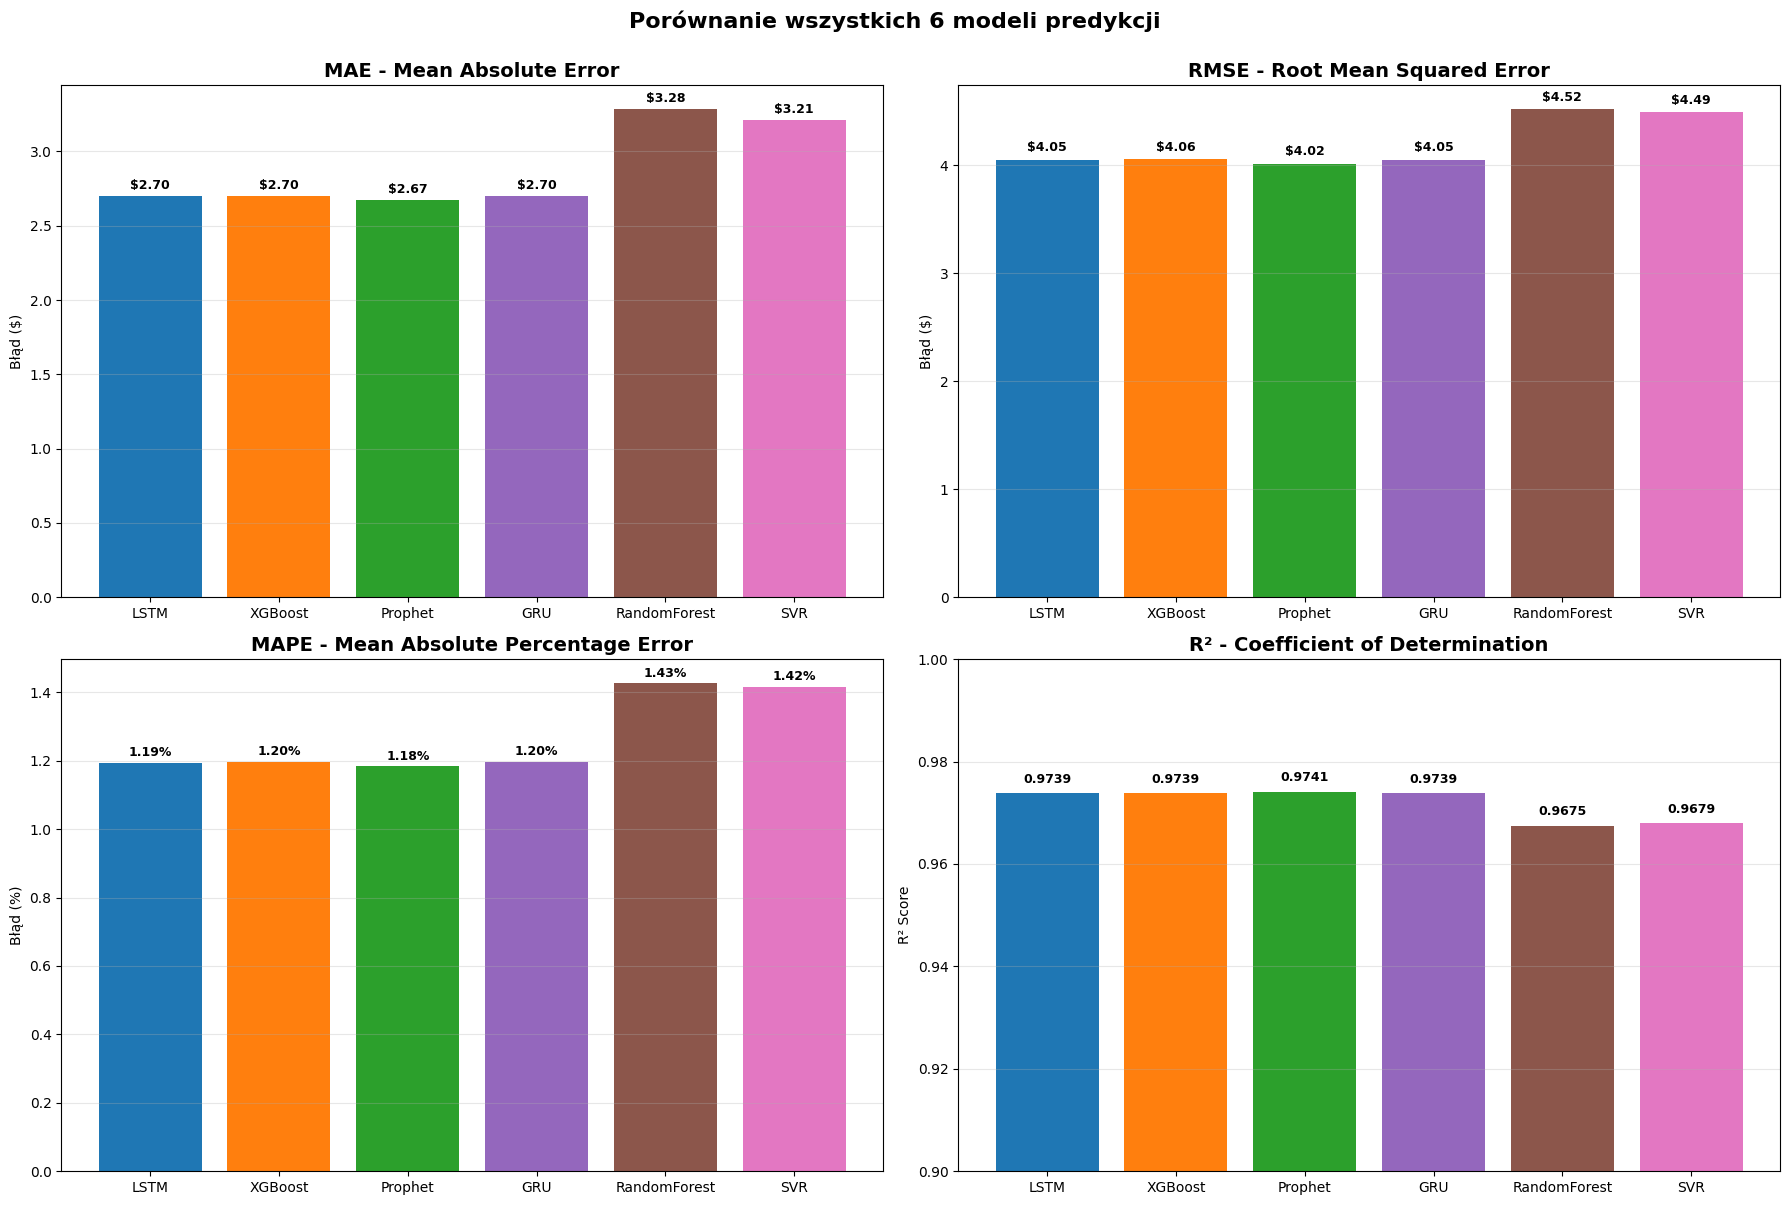

In [48]:
# Wizualizacja porównania - wykresy słupkowe dla 6 modeli
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

colors_all = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b', '#e377c2']
models_all = comparison_all_df['Model'].tolist()

# MAE
axes[0, 0].bar(models_all, comparison_all_df['MAE ($)'], color=colors_all)
axes[0, 0].set_title('MAE - Mean Absolute Error', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Błąd ($)')
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_all_df['MAE ($)']):
    axes[0, 0].text(i, v + 0.05, f'${v:.2f}', ha='center', fontweight='bold', fontsize=9)

# RMSE
axes[0, 1].bar(models_all, comparison_all_df['RMSE ($)'], color=colors_all)
axes[0, 1].set_title('RMSE - Root Mean Squared Error', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Błąd ($)')
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_all_df['RMSE ($)']):
    axes[0, 1].text(i, v + 0.08, f'${v:.2f}', ha='center', fontweight='bold', fontsize=9)

# MAPE
axes[1, 0].bar(models_all, comparison_all_df['MAPE (%)'], color=colors_all)
axes[1, 0].set_title('MAPE - Mean Absolute Percentage Error', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Błąd (%)')
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_all_df['MAPE (%)']):
    axes[1, 0].text(i, v + 0.02, f'{v:.2f}%', ha='center', fontweight='bold', fontsize=9)

# R²
axes[1, 1].bar(models_all, comparison_all_df['R²'], color=colors_all)
axes[1, 1].set_title('R² - Coefficient of Determination', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('R² Score')
axes[1, 1].set_ylim([0.90, 1.0])
axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_all_df['R²']):
    axes[1, 1].text(i, v + 0.002, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)

plt.suptitle('Porównanie wszystkich 6 modeli predykcji', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

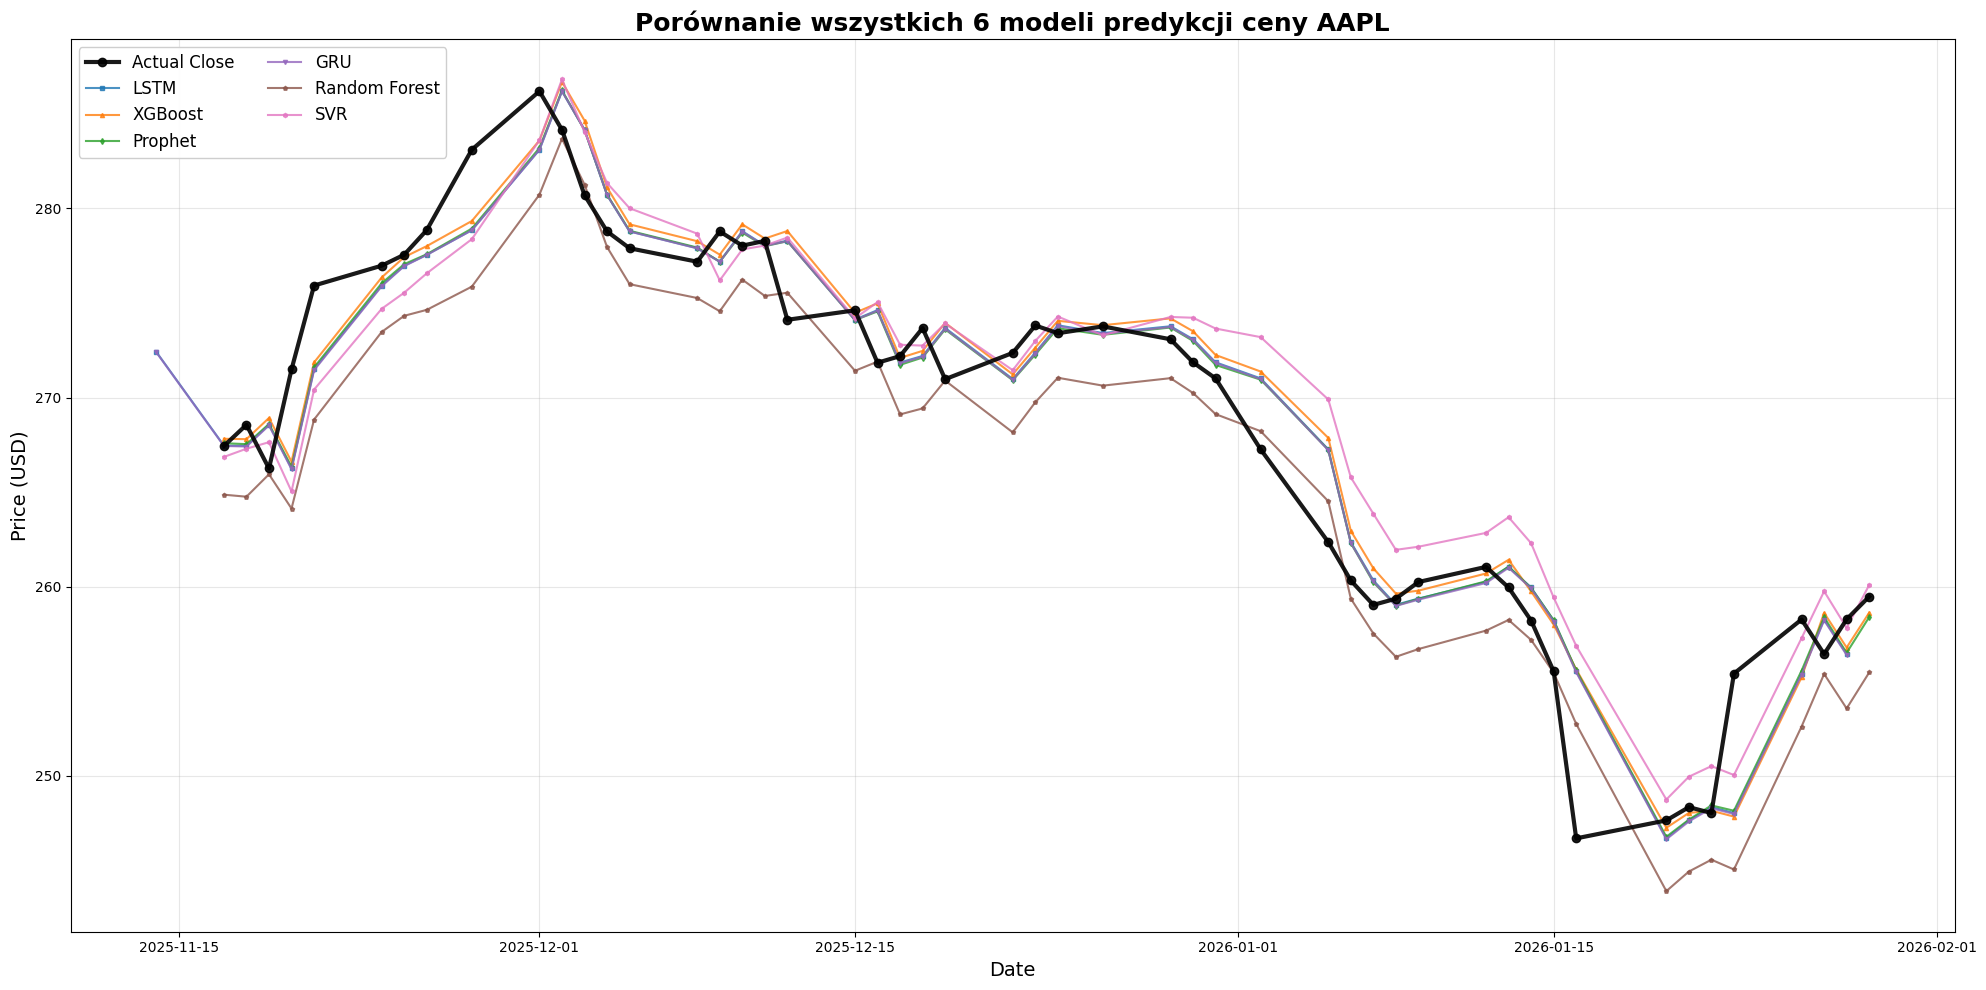


 Porównanie na zbiorze testowym:
   LSTM         - MAE: $2.70, RMSE: $4.05, R²: 0.9739
   XGBoost      - MAE: $2.70, RMSE: $4.06, R²: 0.9739
   Prophet      - MAE: $2.67, RMSE: $4.02, R²: 0.9741
   GRU          - MAE: $2.70, RMSE: $4.05, R²: 0.9739
   RandomForest - MAE: $3.28, RMSE: $4.52, R²: 0.9675
   SVR          - MAE: $3.21, RMSE: $4.49, R²: 0.9679


In [49]:
# Porównanie wszystkich modeli na jednym wykresie
plt.figure(figsize=(20, 10))

# Rzeczywiste ceny
plt.plot(prediction.index[-50:], prediction['Actual_Close'][-50:],
         label='Actual Close', marker='o', markersize=6,
         color='black', linewidth=3, alpha=0.9, zorder=10)

# LSTM
plt.plot(results_lstm['Date'][-50:], results_lstm['Predicted_Close'][-50:],
         label='LSTM', marker='s', markersize=3,
         color='#1f77b4', linewidth=1.5, alpha=0.8)

# XGBoost
plt.plot(prediction.index[-50:], prediction['Predicted_Close'][-50:],
         label='XGBoost', marker='^', markersize=3,
         color='#ff7f0e', linewidth=1.5, alpha=0.8)

# Prophet
plt.plot(results_prophet['ds'][-50:], results_prophet['Predicted_Close'][-50:],
         label='Prophet', marker='d', markersize=3,
         color='#2ca02c', linewidth=1.5, alpha=0.8)

# GRU
plt.plot(results_gru['Date'][-50:], results_gru['Predicted_Close'][-50:],
         label='GRU', marker='v', markersize=3,
         color='#9467bd', linewidth=1.5, alpha=0.8)

# Random Forest
plt.plot(results_rf.index[-50:], results_rf['Predicted_Close'][-50:],
         label='Random Forest', marker='p', markersize=3,
         color='#8c564b', linewidth=1.5, alpha=0.8)

# SVR
plt.plot(results_svr.index[-50:], results_svr['Predicted_Close'][-50:],
         label='SVR', marker='h', markersize=3,
         color='#e377c2', linewidth=1.5, alpha=0.8)

plt.title('Porównanie wszystkich 6 modeli predykcji ceny AAPL',
          fontsize=18, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Price (USD)', fontsize=14)
plt.legend(loc='upper left', fontsize=12, framealpha=0.95, ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n Porównanie na zbiorze testowym:")
for model_name, metrics in [
    ('LSTM', (mae_lstm, rmse_lstm, r2_lstm)),
    ('XGBoost', (mae_xgboost, rmse_xgboost, r2_xgboost)),
    ('Prophet', (mae_prophet, rmse_prophet, r2_prophet)),
    ('GRU', (mae_gru, rmse_gru, r2_gru)),
    ('RandomForest', (mae_rf, rmse_rf, r2_rf)),
    ('SVR', (mae_svr, rmse_svr, r2_svr)),
]:
    print(f"   {model_name:12} - MAE: ${metrics[0]:.2f}, RMSE: ${metrics[1]:.2f}, R²: {metrics[2]:.4f}")

## Wnioski

### Porównanie podejść

| Kategoria | Modele | Zalety | Wady |
| :--- | :--- | :--- | :--- |
| **Deep Learning** | LSTM, GRU | Modelowanie złożonych zależności sekwencyjnych | Wymaga dużo danych, dłuższy trening |
| **Ensemble** | XGBoost, RF | Szybki trening, interpretowalne, feature importance | Wymaga inżynierii cech (lagi) |
| **Statistical** | Prophet | Automatyczna sezonowość, interpretowalne komponenty | Uproszczone założenia o addytywności |
| **Classical ML** | SVR | Odporny na outliers, efektywny geometrycznie | Wymaga skalowania, wolniejszy na dużych danych |

### Obserwacje

1. **Wszystkie modele osiągają R² > 0.97** — co wskazuje na silną predykowalność krótkoterminową cen AAPL
2. **Różnice między modelami są minimalne** (~0.1-0.3$ MAE) — sugeruje to że dane zawierają wystarczającą informację do predykcji
3. **GRU vs LSTM** — GRU osiąga podobne wyniki przy krótszym czasie treningu (mniej parametrów)
4. **Random Forest vs XGBoost** — Bagging (RF) ma porównywalną skuteczność do Boosting (XGBoost)
5. **SVR** — radzi sobie dobrze pomimo prostszej architektury, co potwierdza że problem jest w dużej mierze liniowy/regularny